Load in the dataset

In [3]:
import pandas as pd

file_path = '//content/GSE267287_PCOS_MPC_readcount_table.txt.gz'
delimiter = '\t'                    #tab-seperated
try:
    # Read the .txt file into a pandas DataFrame
    df_txt = pd.read_csv(file_path, delimiter=delimiter)

    print(f"Successfully loaded '{file_path}' into a DataFrame!")
    print("Here are the first 5 rows:")
    display(df_txt.head())

    print("\nDataFrame Info:")
    df_txt.info()

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path.")

Successfully loaded '//content/GSE267287_PCOS_MPC_readcount_table.txt.gz' into a DataFrame!
Here are the first 5 rows:


,0,N11311_13,N11311_14,N11311_15,N11311_16,N11311_03,N11311_04,N11311_05,N11311_07,N11311_08,N11311_09,N11311_10,N11311_11,N11311_17,N11311_18
0,ENSG00000223972.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,ENSG00000227232.5,42,52,39,75,44,65,53,26,41,18,40,32,42,58
2,ENSG00000278267.1,4,3,6,16,10,8,13,1,22,2,17,8,7,6
3,ENSG00000243485.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,ENSG00000284332.1,0,0,0,0,0,0,0,0,0,0,0,0,0,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   0          60715 non-null  object
 1   N11311_13  60715 non-null  int64 
 2   N11311_14  60715 non-null  int64 
 3   N11311_15  60715 non-null  int64 
 4   N11311_16  60715 non-null  int64 
 5   N11311_03  60715 non-null  int64 
 6   N11311_04  60715 non-null  int64 
 7   N11311_05  60715 non-null  int64 
 8   N11311_07  60715 non-null  int64 
 9   N11311_08  60715 non-null  int64 
 10  N11311_09  60715 non-null  int64 
 11  N11311_10  60715 non-null  int64 
 12  N11311_11  60715 non-null  int64 
 13  N11311_17  60715 non-null  int64 
 14  N11311_18  60715 non-null  int64 
dtypes: int64(14), object(1)
memory usage: 6.9+ MB


Mapping the sample columns to the provided descriptive names.

In [4]:
# Extract the current sample column names from df_txt (excluding the first column '0')
current_sample_columns = df_txt.columns[1:].tolist()

# The descriptive names provided by the dataset
new_sample_names = [
    'C25',
    'C25 w/ testosterone',
    'C24',
    'C24 w/ testosterone',
    'C31',
    'C31 w/ testosterone',
    'C32',
    'P2',
    'P2 w/ testosterone',
    'P5',
    'P5 w/ testosterone',
    'P11',
    'P12',
    'P12 w/ testosterone'
]

# Create a mapping dictionary
# Check to ensure the number of columns matches the number of new names
if len(current_sample_columns) == len(new_sample_names):
    column_rename_map = dict(zip(current_sample_columns, new_sample_names))

    # Rename the columns in the DataFrame
    df_txt_renamed = df_txt.rename(columns=column_rename_map)

    print("Successfully renamed the sample columns. Here are the first 5 rows with new names:")
    display(df_txt_renamed.head())

    print("\nUpdated DataFrame Info:")
    df_txt_renamed.info()

    # Update df_txt to the renamed DataFrame
    df_txt = df_txt_renamed

else:
    print(f"Error: Number of existing sample columns ({len(current_sample_columns)}) does not match the number of provided new names ({len(new_sample_names)}).")
    print("Please ensure the lists are of equal length for accurate mapping.")

Successfully renamed the sample columns. Here are the first 5 rows with new names:


,0,C25,C25 w/ testosterone,C24,C24 w/ testosterone,C31,C31 w/ testosterone,C32,P2,P2 w/ testosterone,P5,P5 w/ testosterone,P11,P12,P12 w/ testosterone
0,ENSG00000223972.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,ENSG00000227232.5,42,52,39,75,44,65,53,26,41,18,40,32,42,58
2,ENSG00000278267.1,4,3,6,16,10,8,13,1,22,2,17,8,7,6
3,ENSG00000243485.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,ENSG00000284332.1,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   0                    60715 non-null  object
 1   C25                  60715 non-null  int64 
 2   C25 w/ testosterone  60715 non-null  int64 
 3   C24                  60715 non-null  int64 
 4   C24 w/ testosterone  60715 non-null  int64 
 5   C31                  60715 non-null  int64 
 6   C31 w/ testosterone  60715 non-null  int64 
 7   C32                  60715 non-null  int64 
 8   P2                   60715 non-null  int64 
 9   P2 w/ testosterone   60715 non-null  int64 
 10  P5                   60715 non-null  int64 
 11  P5 w/ testosterone   60715 non-null  int64 
 12  P11                  60715 non-null  int64 
 13  P12                  60715 non-null  int64 
 14  P12 w/ testosterone  60715 non-null  int64 
dtypes: int64(14), object(1)
memo

Separate the DataFrame into controls and PCOS samples. Columns that start with 'C' are control samples and columns that start with 'P' are PCOS samples.

In [5]:
# Assuming the first column (index 0) contains identifiers and should be kept in both dataframes
identifier_column = df_txt.columns[0]

# Initialize lists to hold control and PCOS column names, including the identifier column
control_columns = [identifier_column]
PCOS_columns = [identifier_column]

# Iterate through the rest of the columns to categorize them
for col in df_txt.columns[1:]:
    if col.startswith('C'):
        control_columns.append(col)
    elif col.startswith('P'):
        PCOS_columns.append(col)

# Create the new DataFrames
df_control = df_txt[control_columns].copy()
df_PCOS = df_txt[PCOS_columns].copy()

print("DataFrame for Control samples (first 5 rows):")
display(df_control.head())
print("\nControl DataFrame Info:")
df_control.info()

print("\nDataFrame for PCOS samples (first 5 rows):")
display(df_PCOS.head())
print("\nPCOS DataFrame Info:")
df_PCOS.info()

DataFrame for Control samples (first 5 rows):


,0,C25,C25 w/ testosterone,C24,C24 w/ testosterone,C31,C31 w/ testosterone,C32
0,ENSG00000223972.5,0,0,0,0,0,0,0
1,ENSG00000227232.5,42,52,39,75,44,65,53
2,ENSG00000278267.1,4,3,6,16,10,8,13
3,ENSG00000243485.5,0,0,0,0,0,0,0
4,ENSG00000284332.1,0,0,0,0,0,0,0



Control DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   0                    60715 non-null  object
 1   C25                  60715 non-null  int64 
 2   C25 w/ testosterone  60715 non-null  int64 
 3   C24                  60715 non-null  int64 
 4   C24 w/ testosterone  60715 non-null  int64 
 5   C31                  60715 non-null  int64 
 6   C31 w/ testosterone  60715 non-null  int64 
 7   C32                  60715 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 3.7+ MB

DataFrame for PCOS samples (first 5 rows):


,0,P2,P2 w/ testosterone,P5,P5 w/ testosterone,P11,P12,P12 w/ testosterone
0,ENSG00000223972.5,0,0,0,0,0,0,0
1,ENSG00000227232.5,26,41,18,40,32,42,58
2,ENSG00000278267.1,1,22,2,17,8,7,6
3,ENSG00000243485.5,0,0,0,0,0,0,0
4,ENSG00000284332.1,0,0,0,0,0,0,0



PCOS DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   0                    60715 non-null  object
 1   P2                   60715 non-null  int64 
 2   P2 w/ testosterone   60715 non-null  int64 
 3   P5                   60715 non-null  int64 
 4   P5 w/ testosterone   60715 non-null  int64 
 5   P11                  60715 non-null  int64 
 6   P12                  60715 non-null  int64 
 7   P12 w/ testosterone  60715 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 3.7+ MB


To further refine our datasets, separate the `df_control` and `df_PCOS` DataFrames into four distinct groups:

1.  **Control (without testosterone)**: Samples from the control group that did not receive testosterone.
2.  **Control (with testosterone)**: Samples from the control group that received testosterone.
3.  **PCOS (without testosterone)**: Samples from the PCOS group that did not receive testosterone.
4.  **PCOS (with testosterone)**: Samples from the PCOS group that received testosterone.



In [6]:
# Assuming the first column (identifier_column) is '0'
identifier_column = df_control.columns[0]

# --- Separate Control Samples ---
control_no_testosterone_columns = [identifier_column]
control_w_testosterone_columns = [identifier_column]

for col in df_control.columns[1:]:
    if 'w/ testosterone' in col:
        control_w_testosterone_columns.append(col)
    else:
        control_no_testosterone_columns.append(col)

df_control_no_testosterone = df_control[control_no_testosterone_columns].copy()
df_control_w_testosterone = df_control[control_w_testosterone_columns].copy()

print("DataFrame for Control samples (without testosterone, first 5 rows):")
display(df_control_no_testosterone.head())
print("\nControl (without testosterone) DataFrame Info:")
df_control_no_testosterone.info()

print("\nDataFrame for Control samples (with testosterone, first 5 rows):")
display(df_control_w_testosterone.head())
print("\nControl (with testosterone) DataFrame Info:")
df_control_w_testosterone.info()

# --- Separate PCOS Samples ---
PCOS_no_testosterone_columns = [identifier_column]
PCOS_w_testosterone_columns = [identifier_column]

for col in df_PCOS.columns[1:]:
    if 'w/ testosterone' in col:
        PCOS_w_testosterone_columns.append(col)
    else:
        PCOS_no_testosterone_columns.append(col)

df_PCOS_no_testosterone = df_PCOS[PCOS_no_testosterone_columns].copy()
df_PCOS_w_testosterone = df_PCOS[PCOS_w_testosterone_columns].copy()

print("\nDataFrame for PCOS samples (without testosterone, first 5 rows):")
display(df_PCOS_no_testosterone.head())
print("\nPCOS (without testosterone) DataFrame Info:")
df_PCOS_no_testosterone.info()

print("\nDataFrame for PCOS samples (with testosterone, first 5 rows):")
display(df_PCOS_w_testosterone.head())
print("\nPCOS (with testosterone) DataFrame Info:")
df_PCOS_w_testosterone.info()

DataFrame for Control samples (without testosterone, first 5 rows):


,0,C25,C24,C31,C32
0,ENSG00000223972.5,0,0,0,0
1,ENSG00000227232.5,42,39,44,53
2,ENSG00000278267.1,4,6,10,13
3,ENSG00000243485.5,0,0,0,0
4,ENSG00000284332.1,0,0,0,0



Control (without testosterone) DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       60715 non-null  object
 1   C25     60715 non-null  int64 
 2   C24     60715 non-null  int64 
 3   C31     60715 non-null  int64 
 4   C32     60715 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 2.3+ MB

DataFrame for Control samples (with testosterone, first 5 rows):


,0,C25 w/ testosterone,C24 w/ testosterone,C31 w/ testosterone
0,ENSG00000223972.5,0,0,0
1,ENSG00000227232.5,52,75,65
2,ENSG00000278267.1,3,16,8
3,ENSG00000243485.5,0,0,0
4,ENSG00000284332.1,0,0,0



Control (with testosterone) DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   0                    60715 non-null  object
 1   C25 w/ testosterone  60715 non-null  int64 
 2   C24 w/ testosterone  60715 non-null  int64 
 3   C31 w/ testosterone  60715 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.9+ MB

DataFrame for PCOS samples (without testosterone, first 5 rows):


,0,P2,P5,P11,P12
0,ENSG00000223972.5,0,0,0,0
1,ENSG00000227232.5,26,18,32,42
2,ENSG00000278267.1,1,2,8,7
3,ENSG00000243485.5,0,0,0,0
4,ENSG00000284332.1,0,0,0,0



PCOS (without testosterone) DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       60715 non-null  object
 1   P2      60715 non-null  int64 
 2   P5      60715 non-null  int64 
 3   P11     60715 non-null  int64 
 4   P12     60715 non-null  int64 
dtypes: int64(4), object(1)
memory usage: 2.3+ MB

DataFrame for PCOS samples (with testosterone, first 5 rows):


,0,P2 w/ testosterone,P5 w/ testosterone,P12 w/ testosterone
0,ENSG00000223972.5,0,0,0
1,ENSG00000227232.5,41,40,58
2,ENSG00000278267.1,22,17,6
3,ENSG00000243485.5,0,0,0
4,ENSG00000284332.1,0,0,0



PCOS (with testosterone) DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60715 entries, 0 to 60714
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   0                    60715 non-null  object
 1   P2 w/ testosterone   60715 non-null  int64 
 2   P5 w/ testosterone   60715 non-null  int64 
 3   P12 w/ testosterone  60715 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.9+ MB


# Differential Gene Expression Analysis

First, I'll install the `pydeseq2` library for differential gene expression analysis.

In [7]:
!pip install pydeseq2 -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.4/174.4 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 8.8 MB/s eta 0:00:00


Now that `pydeseq2` is installed,prepare the data in the format required by the library. This involves:

1.  **Creating a `counts_df`**: A DataFrame containing raw gene counts, with gene identifiers as the index and sample names as columns.
2.  **Creating a `clinical_df`**: A DataFrame containing metadata for each sample, with sample names as the index and a column indicating the experimental condition (e.g., 'control' or 'PCOS').

Combine `df_control_no_testosterone` and `df_PCOS_no_testosterone` to create these inputs.

In [8]:
import pandas as pd
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

# Assuming the identifier column is '0'
identifier_column = '0'

# --- Prepare counts_df ---
# Set the identifier column as index for both dataframes
df_control_no_testosterone_indexed = df_control_no_testosterone.set_index(identifier_column)
df_PCOS_no_testosterone_indexed = df_PCOS_no_testosterone.set_index(identifier_column)

# Concatenate the dataframes to form the counts_df
# Ensure columns are only count data (excluding the identifier column)
counts_df = pd.concat([
    df_control_no_testosterone_indexed.drop(columns=[], errors='ignore'),
    df_PCOS_no_testosterone_indexed.drop(columns=[], errors='ignore')
], axis=1)

# Transpose counts_df so samples are rows and genes are columns
counts_df = counts_df.T

# Ensure all counts are integers
counts_df = counts_df.astype(int)

print("Counts DataFrame (first 5 rows):")
display(counts_df.head())
print("\nCounts DataFrame Info:")
counts_df.info()

# --- Prepare clinical_df ---
sample_names = counts_df.index.tolist() # Changed to use the index (samples) of the transposed counts_df

# Create a list of conditions based on sample names
conditions = []
for sample in sample_names:
    if sample.startswith('C'):
        conditions.append('control')
    elif sample.startswith('P'):
        conditions.append('PCOS')
    else:
        conditions.append('unknown') # Should not happen with current data

clinical_df = pd.DataFrame({
    'condition': conditions
}, index=sample_names)

print("\nClinical DataFrame:")
display(clinical_df)
print("\nClinical DataFrame Info:")
clinical_df.info()

Counts DataFrame (first 5 rows):


0,ENSG00000223972.5,ENSG00000227232.5,ENSG00000278267.1,ENSG00000243485.5,ENSG00000284332.1,ENSG00000237613.2,ENSG00000268020.3,ENSG00000240361.2,ENSG00000186092.6,ENSG00000238009.6,...,ENSG00000273739.1,ENSG00000276700.1,ENSG00000276312.1,ENSG00000275757.1,ENSG00000278573.1,ENSG00000276017.1,ENSG00000278817.1,ENSG00000277196.4,ENSG00000278625.1,ENSG00000277374.1
C25,0,42,4,0,0,0,0,0,0,8,...,0,1,0,0,0,0,16,2,0,0
C24,0,39,6,0,0,0,0,0,0,14,...,0,4,0,1,0,0,8,13,0,0
C31,0,44,10,0,0,0,0,0,0,3,...,0,1,0,0,0,0,8,30,0,0
C32,0,53,13,0,0,0,0,0,0,0,...,0,0,0,0,0,0,31,51,0,0
P2,0,26,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,23,43,0,0



Counts DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, C25 to P12
Columns: 60715 entries, ENSG00000223972.5 to ENSG00000277374.1
dtypes: int64(60715)
memory usage: 3.7+ MB

Clinical DataFrame:


,condition
C25,control
C24,control
C31,control
C32,control
P2,PCOS
P5,PCOS
P11,PCOS
P12,PCOS



Clinical DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, C25 to P12
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   condition  8 non-null      object
dtypes: object(1)
memory usage: 428.0+ bytes


In [9]:
# Create a DeseqDataSet object
dds = DeseqDataSet(
    counts=counts_df,
    metadata=clinical_df,
    design_factors=['condition'],
    refit_cooks=True,
    inference=DefaultInference(n_cpus=8) # Use multiple CPUs for faster computation if available
)

# Run the DESeq2 pipeline
dds.deseq2()

# Perform differential expression testing
# Comparing 'PCOS' condition against the 'control' condition (which is the reference level by default)
stat_res = DeseqStats(dds, contrast=['condition', 'PCOS', 'control'])
stat_res.summary()

# Get the results DataFrame
differential_expression_results = stat_res.results_df

print("Differential Expression Analysis Results (first 10 rows, sorted by p-value):")
# Sort by adjusted p-value to see the most significant genes first
display(differential_expression_results.sort_values('padj').head(10))

Using None as control genes, passed at DeseqDataSet initialization


/tmp/ipykernel_18180/2163048366.py:2: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 34.49 seconds.

Fitting dispersion trend curve...
/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)
... done in 0.86 seconds.

Fitting MAP dispersions...
... done in 47.59 seconds.

Fitting LFCs...
... done in 27.24 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 13.86 seconds.



Log2 fold change & Wald test p-value: condition PCOS vs control
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
0                                                                            
ENSG00000223972.5   0.000000             NaN       NaN       NaN       NaN   
ENSG00000227232.5  35.801703       -0.468821  0.253536 -1.849129  0.064439   
ENSG00000278267.1   6.057065       -0.798238  0.693106 -1.151683  0.249451   
ENSG00000243485.5   0.000000             NaN       NaN       NaN       NaN   
ENSG00000284332.1   0.000000             NaN       NaN       NaN       NaN   
...                      ...             ...       ...       ...       ...   
ENSG00000276017.1   0.000000             NaN       NaN       NaN       NaN   
ENSG00000278817.1  17.025742        0.454117  0.611006  0.743228  0.457344   
ENSG00000277196.4  21.819364       -0.114344  1.077765 -0.106094  0.915508   
ENSG00000278625.1   0.000000             NaN       NaN       NaN       NaN   


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,,,,,,
ENSG00000213058.3,99.189157,-5.762764,0.516882,-11.149089,7.234352e-29,1.320993e-24
ENSG00000214455.4,359.752208,1.532459,0.178633,8.578802,9.586651e-18,8.752613e-14
ENSG00000160221.18,39.511545,3.805188,0.584216,6.513327,7.350449e-11,4.473973e-07
ENSG00000147044.22,3064.329843,-1.207982,0.219002,-5.515844,3.471110e-08,7.822680e-05
ENSG00000114948.13,1355.867224,1.377594,0.249391,5.523832,3.316844e-08,7.822680e-05
ENSG00000239528.1,10.580014,-4.346204,0.776923,-5.594126,2.217364e-08,7.822680e-05
ENSG00000203952.9,46.057753,-1.473164,0.264113,-5.577771,2.436205e-08,7.822680e-05
ENSG00000204991.11,85.177060,0.999740,0.181859,5.497339,3.855648e-08,7.822680e-05
ENSG00000224114.1,113.825111,-2.237788,0.403004,-5.552772,2.811744e-08,7.822680e-05


### Prepare Data for Labeled Volcano Plot

Install a Python-based library like `mygene` to query gene annotation databases and retrieve gene symbols for the Ensembl IDs.

In [10]:
print("Installing mygene library...")
!pip install mygene -qq
print("mygene library installed.")

Installing mygene library...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.1 MB/s eta 0:00:00
mygene library installed.


Extract the Ensembl IDs from the `differentially_expressed_genes` DataFrame and use the `mygene` library to query gene symbols for these IDs. Handle cases where a symbol might not be found or multiple symbols are returned.


In [11]:
import mygene

# Instantiate a MyGeneInfo client
mg = mygene.MyGeneInfo()

print("mygene library imported and MyGeneInfo client instantiated.")

mygene library imported and MyGeneInfo client instantiated.


In [17]:
# Instantiate a MyGeneInfo client (ensure it's instantiated if not already global)
mg = mygene.MyGeneInfo()

# 1. Extract the Ensembl IDs from the index of the differential_expression_results DataFrame
versioned_ensembl_ids = differential_expression_results.index.tolist()

# Create a list of unversioned Ensembl IDs for querying
unversioned_ensembl_ids = [id.split('.')[0] for id in versioned_ensembl_ids]

print(f"Found {len(unversioned_ensembl_ids)} unversioned Ensembl IDs to query.")

# 2. Use the mg.querymany method to query for gene symbols
# This function is specifically designed for batch queries and returns a list of results.
query_results = mg.querymany(
    unversioned_ensembl_ids, # Query with unversioned IDs
    scopes='ensembl.gene',
    fields='symbol',
    species='human',
    as_dataframe=False
)

# 3. Iterate through the query results and extract the gene symbols
# This map will store unversioned_ensembl_id -> symbol
unversioned_gene_symbol_map = {}

# querymany returns a list of dictionaries, one for each queried ID
for res in query_results:
    ensembl_id = res.get('query') # This will be the unversioned ID
    symbol = None
    if ensembl_id:
        # Check if there are 'hits' for this query
        if res.get('symbol'): # mygene.querymany directly puts the symbol at the top level if found
            symbol = res['symbol']
        elif res.get('alias'): # Fallback to alias
            symbol = res['alias']

    unversioned_gene_symbol_map[ensembl_id] = symbol


print("\nFirst 10 entries of the unversioned Ensembl ID to Gene Symbol mapping:")
# Display first 10 items of the dictionary
for i, (ensembl, symbol) in enumerate(unversioned_gene_symbol_map.items()):
    if i >= 10:
        break
    print(f"{ensembl}: {symbol}")

# Add the gene symbols to the differential_expression_results DataFrame
# The DataFrame index contains versioned IDs, so we need to strip the version to lookup in unversioned_gene_symbol_map
differential_expression_results['GeneSymbol'] = differential_expression_results.index.map(
    lambda x: unversioned_gene_symbol_map.get(x.split('.')[0])
)

print("\nDifferentially expressed genes with new 'GeneSymbol' column (first 5 rows):")
display(differential_expression_results)

INFO:biothings.client:querying 1-1000 ...


Found 60715 unversioned Ensembl IDs to query.


INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 21001-22000 ...
INFO:biothings.client:querying


First 10 entries of the unversioned Ensembl ID to Gene Symbol mapping:
ENSG00000223972: DDX11L1
ENSG00000227232: WASH7P
ENSG00000278267: MIR6859-1
ENSG00000243485: MIR1302-2HG
ENSG00000284332: MIR1302-2
ENSG00000237613: FAM138A
ENSG00000268020: OR4G4P
ENSG00000240361: OR4G11P
ENSG00000186092: OR4F5
ENSG00000238009: None

Differentially expressed genes with new 'GeneSymbol' column (first 5 rows):


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneSymbol
0,,,,,,,
ENSG00000223972.5,0.000000,NaN,NaN,NaN,NaN,NaN,DDX11L1
ENSG00000227232.5,35.801703,-0.468821,0.253536,-1.849129,0.064439,0.793249,WASH7P
ENSG00000278267.1,6.057065,-0.798238,0.693106,-1.151683,0.249451,0.999348,MIR6859-1
ENSG00000243485.5,0.000000,NaN,NaN,NaN,NaN,NaN,MIR1302-2HG
ENSG00000284332.1,0.000000,NaN,NaN,NaN,NaN,NaN,MIR1302-2
...,...,...,...,...,...,...,...
ENSG00000276017.1,0.000000,NaN,NaN,NaN,NaN,NaN,None
ENSG00000278817.1,17.025742,0.454117,0.611006,0.743228,0.457344,0.999348,None
ENSG00000277196.4,21.819364,-0.114344,1.077765,-0.106094,0.915508,0.999348,None


In [20]:
print("Top 20 differentially expressed genes (sorted by adjusted p-value):")
display(differential_expression_results[['GeneSymbol', 'log2FoldChange', 'padj']].sort_values('padj').head(86))

Top 20 differentially expressed genes (sorted by adjusted p-value):


,GeneSymbol,log2FoldChange,padj
0,,,
ENSG00000213058.3,None,-5.762764,1.320993e-24
ENSG00000214455.4,RCN1P2,1.532459,8.752613e-14
ENSG00000160221.18,GATD3,3.805188,4.473973e-07
ENSG00000147044.22,CASK,-1.207982,7.822680e-05
ENSG00000114948.13,ADAM23,1.377594,7.822680e-05
...,...,...,...
ENSG00000124588.21,NQO2,-0.533130,3.920846e-02
ENSG00000119227.8,PIGZ,1.477457,4.426080e-02
ENSG00000104886.12,PLEKHJ1,-0.431672,4.562313e-02


Export the `differentially_expressed_genes` DataFrame, which contains the 86 genes and their associated information, to a CSV file.


In [22]:
import pandas as pd

# 1. Reset the index of the differentially_expressed_genes DataFrame
df_to_export = differential_expression_results.reset_index()

# Rename the index column to 'EnsemblID' for clarity
df_to_export = df_to_export.rename(columns={'index': 'EnsemblID'})

# 2. Export the df_to_export DataFrame to a CSV file
output_filename = 'differentially_expressed_genes.csv'
df_to_export.to_csv(output_filename, index=False)

print(f"Successfully exported differentially expressed genes to '{output_filename}'")
print("Here are the first 5 rows of the exported DataFrame:")
display(df_to_export.head())

Successfully exported differentially expressed genes to 'differentially_expressed_genes.csv'
Here are the first 5 rows of the exported DataFrame:


,0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneSymbol
0,ENSG00000223972.5,0.000000,NaN,NaN,NaN,NaN,NaN,DDX11L1
1,ENSG00000227232.5,35.801703,-0.468821,0.253536,-1.849129,0.064439,0.793249,WASH7P
2,ENSG00000278267.1,6.057065,-0.798238,0.693106,-1.151683,0.249451,0.999348,MIR6859-1
3,ENSG00000243485.5,0.000000,NaN,NaN,NaN,NaN,NaN,MIR1302-2HG
4,ENSG00000284332.1,0.000000,NaN,NaN,NaN,NaN,NaN,MIR1302-2


In [34]:
import numpy as np

# Start with the differentially_expressed_genes DataFrame, which already has GeneSymbol
# Make a copy to avoid modifying the original DataFrame and drop NaNs for plotting
plot_df_labeled = differential_expression_results.copy().dropna(subset=['log2FoldChange', 'padj'])

# The original 'plot_df' (from cell 52777212) contains all genes, including 'Not significant' ones,
# and already has '-log10(padj)' and 'significance' columns.

# Create a temporary dataframe with all genes (from plot_df) and add GeneSymbol to it.
# First, ensure plot_df has the same structure and calculated columns as needed for display.
all_genes_plot_df = plot_df_labeled.copy().dropna(subset=['log2FoldChange', 'padj'])

# Add the GeneSymbol to all_genes_plot_df by mapping from the unversioned_gene_symbol_map
# The index of all_genes_plot_df are versioned Ensembl IDs, so we need to strip the version
all_genes_plot_df['GeneSymbol'] = all_genes_plot_df.index.map(
    lambda x: unversioned_gene_symbol_map.get(x.split('.')[0])
)

# Now, plot_df_labeled should be this comprehensive all_genes_plot_df
plot_df_labeled = all_genes_plot_df.copy()

# Ensure the -log10(padj) column exists (should already be there from plot_df)
if '-log10(padj)' not in plot_df_labeled.columns:
    plot_df_labeled['-log10(padj)'] = -np.log10(plot_df_labeled['padj'])

# Define significance thresholds
log2fc_threshold = 0.5
p_adj_threshold = 0.05

# Ensure the 'significance' column exists and is correctly categorized (should already be there from plot_df)
if 'significance' not in plot_df_labeled.columns:
    plot_df_labeled['significance'] = 'Not significant'
    plot_df_labeled.loc[(plot_df_labeled['log2FoldChange'] > log2fc_threshold) & (plot_df_labeled['padj'] < p_adj_threshold), 'significance'] = 'Upregulated'
    plot_df_labeled.loc[(plot_df_labeled['log2FoldChange'] < -log2fc_threshold) & (plot_df_labeled['padj'] < p_adj_threshold), 'significance'] = 'Downregulated'

# Sort plot_df_labeled by 'padj' and select the top 20 genes for labeling
num_labels = 20 # Number of top genes to label
genes_to_label = plot_df_labeled.sort_values('padj').head(num_labels)

print("DataFrame for labeled volcano plot prepared.")
print("First 5 rows of plot_df_labeled:")
display(plot_df_labeled.head())
print(f"\nTop {num_labels} genes selected for labeling (genes_to_label):")
display(genes_to_label[['GeneSymbol', 'log2FoldChange', 'padj']].head())

DataFrame for labeled volcano plot prepared.
First 5 rows of plot_df_labeled:


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,GeneSymbol,-log10(padj),significance
0,,,,,,,,,
ENSG00000227232.5,35.801703,-0.468821,0.253536,-1.849129,0.064439,0.793249,WASH7P,0.100591,Not significant
ENSG00000278267.1,6.057065,-0.798238,0.693106,-1.151683,0.249451,0.999348,MIR6859-1,0.000283,Not significant
ENSG00000268903.1,21.917254,-1.053015,0.442772,-2.378234,0.017396,0.506798,None,0.295166,Not significant
ENSG00000269981.1,23.208252,-0.748116,0.444005,-1.684925,0.092003,0.869994,None,0.060484,Not significant
ENSG00000279457.4,90.266338,0.349692,0.262605,1.331626,0.182983,0.999348,WASH9P,0.000283,Not significant



Top 20 genes selected for labeling (genes_to_label):


,GeneSymbol,log2FoldChange,padj
0,,,
ENSG00000213058.3,None,-5.762764,1.320993e-24
ENSG00000214455.4,RCN1P2,1.532459,8.752613e-14
ENSG00000160221.18,GATD3,3.805188,4.473973e-07
ENSG00000147044.22,CASK,-1.207982,7.822680e-05
ENSG00000114948.13,ADAM23,1.377594,7.822680e-05


In [35]:
print("Installing adjustText library...")
!pip install adjustText -qq
print("adjustText library installed.")

Installing adjustText library...
adjustText library installed.


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

def plot_labeled_volcano(plot_df, genes_to_label, log2fc_threshold, p_adj_threshold, title):
    plt.figure(figsize=(25, 25)) # Increased figure size for better layout
    sns.scatterplot(
        data=plot_df,
        x='log2FoldChange',
        y='-log10(padj)',
        hue='significance',
        palette={'Upregulated': 'red', 'Downregulated': 'blue', 'Not significant': 'grey'},
        s=45, # point size
        alpha=0.7
    )

    # Add significance lines
    plt.axvline(x=log2fc_threshold, color='black', linestyle='--', linewidth=0.8)
    plt.axvline(x=-log2fc_threshold, color='black', linestyle='--', linewidth=0.8)
    plt.axhline(y=-np.log10(p_adj_threshold), color='black', linestyle='--', linewidth=0.8)

    texts = []
    for i, row in genes_to_label.iterrows():
        gene_symbol = row['GeneSymbol'] if pd.notna(row['GeneSymbol']) else i.split('.')[0] # Use Ensembl ID if symbol is None
        texts.append(plt.text(
            row['log2FoldChange'],
            row['-log10(padj)'],
            gene_symbol,
            fontsize=20, # Adjusted font size
            ha='center',
            va='center'
        ))

    # Use adjust_text to prevent overlapping labels
    # Pass the actual coordinates of the labeled genes for the arrows
    adjust_text(texts,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
                x=genes_to_label['log2FoldChange'],
                y=genes_to_label['-log10(padj)'])

    # Set axis limits to zoom in for better readability and provide padding for labels
    plt.xlim(-8,5 )  # Adjusted x-limits to provide more space for all data points and labels
    plt.ylim(0, 15)
    plt.title(title, fontsize = 30)
    plt.xlabel('Log2 Fold Change', fontsize=30)
    plt.ylabel('-log10(Adjusted P-value)', fontsize=30)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(title='Gene Status', fontsize=20, title_fontsize=20, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print("plot_labeled_volcano function defined.")

plot_labeled_volcano function defined.


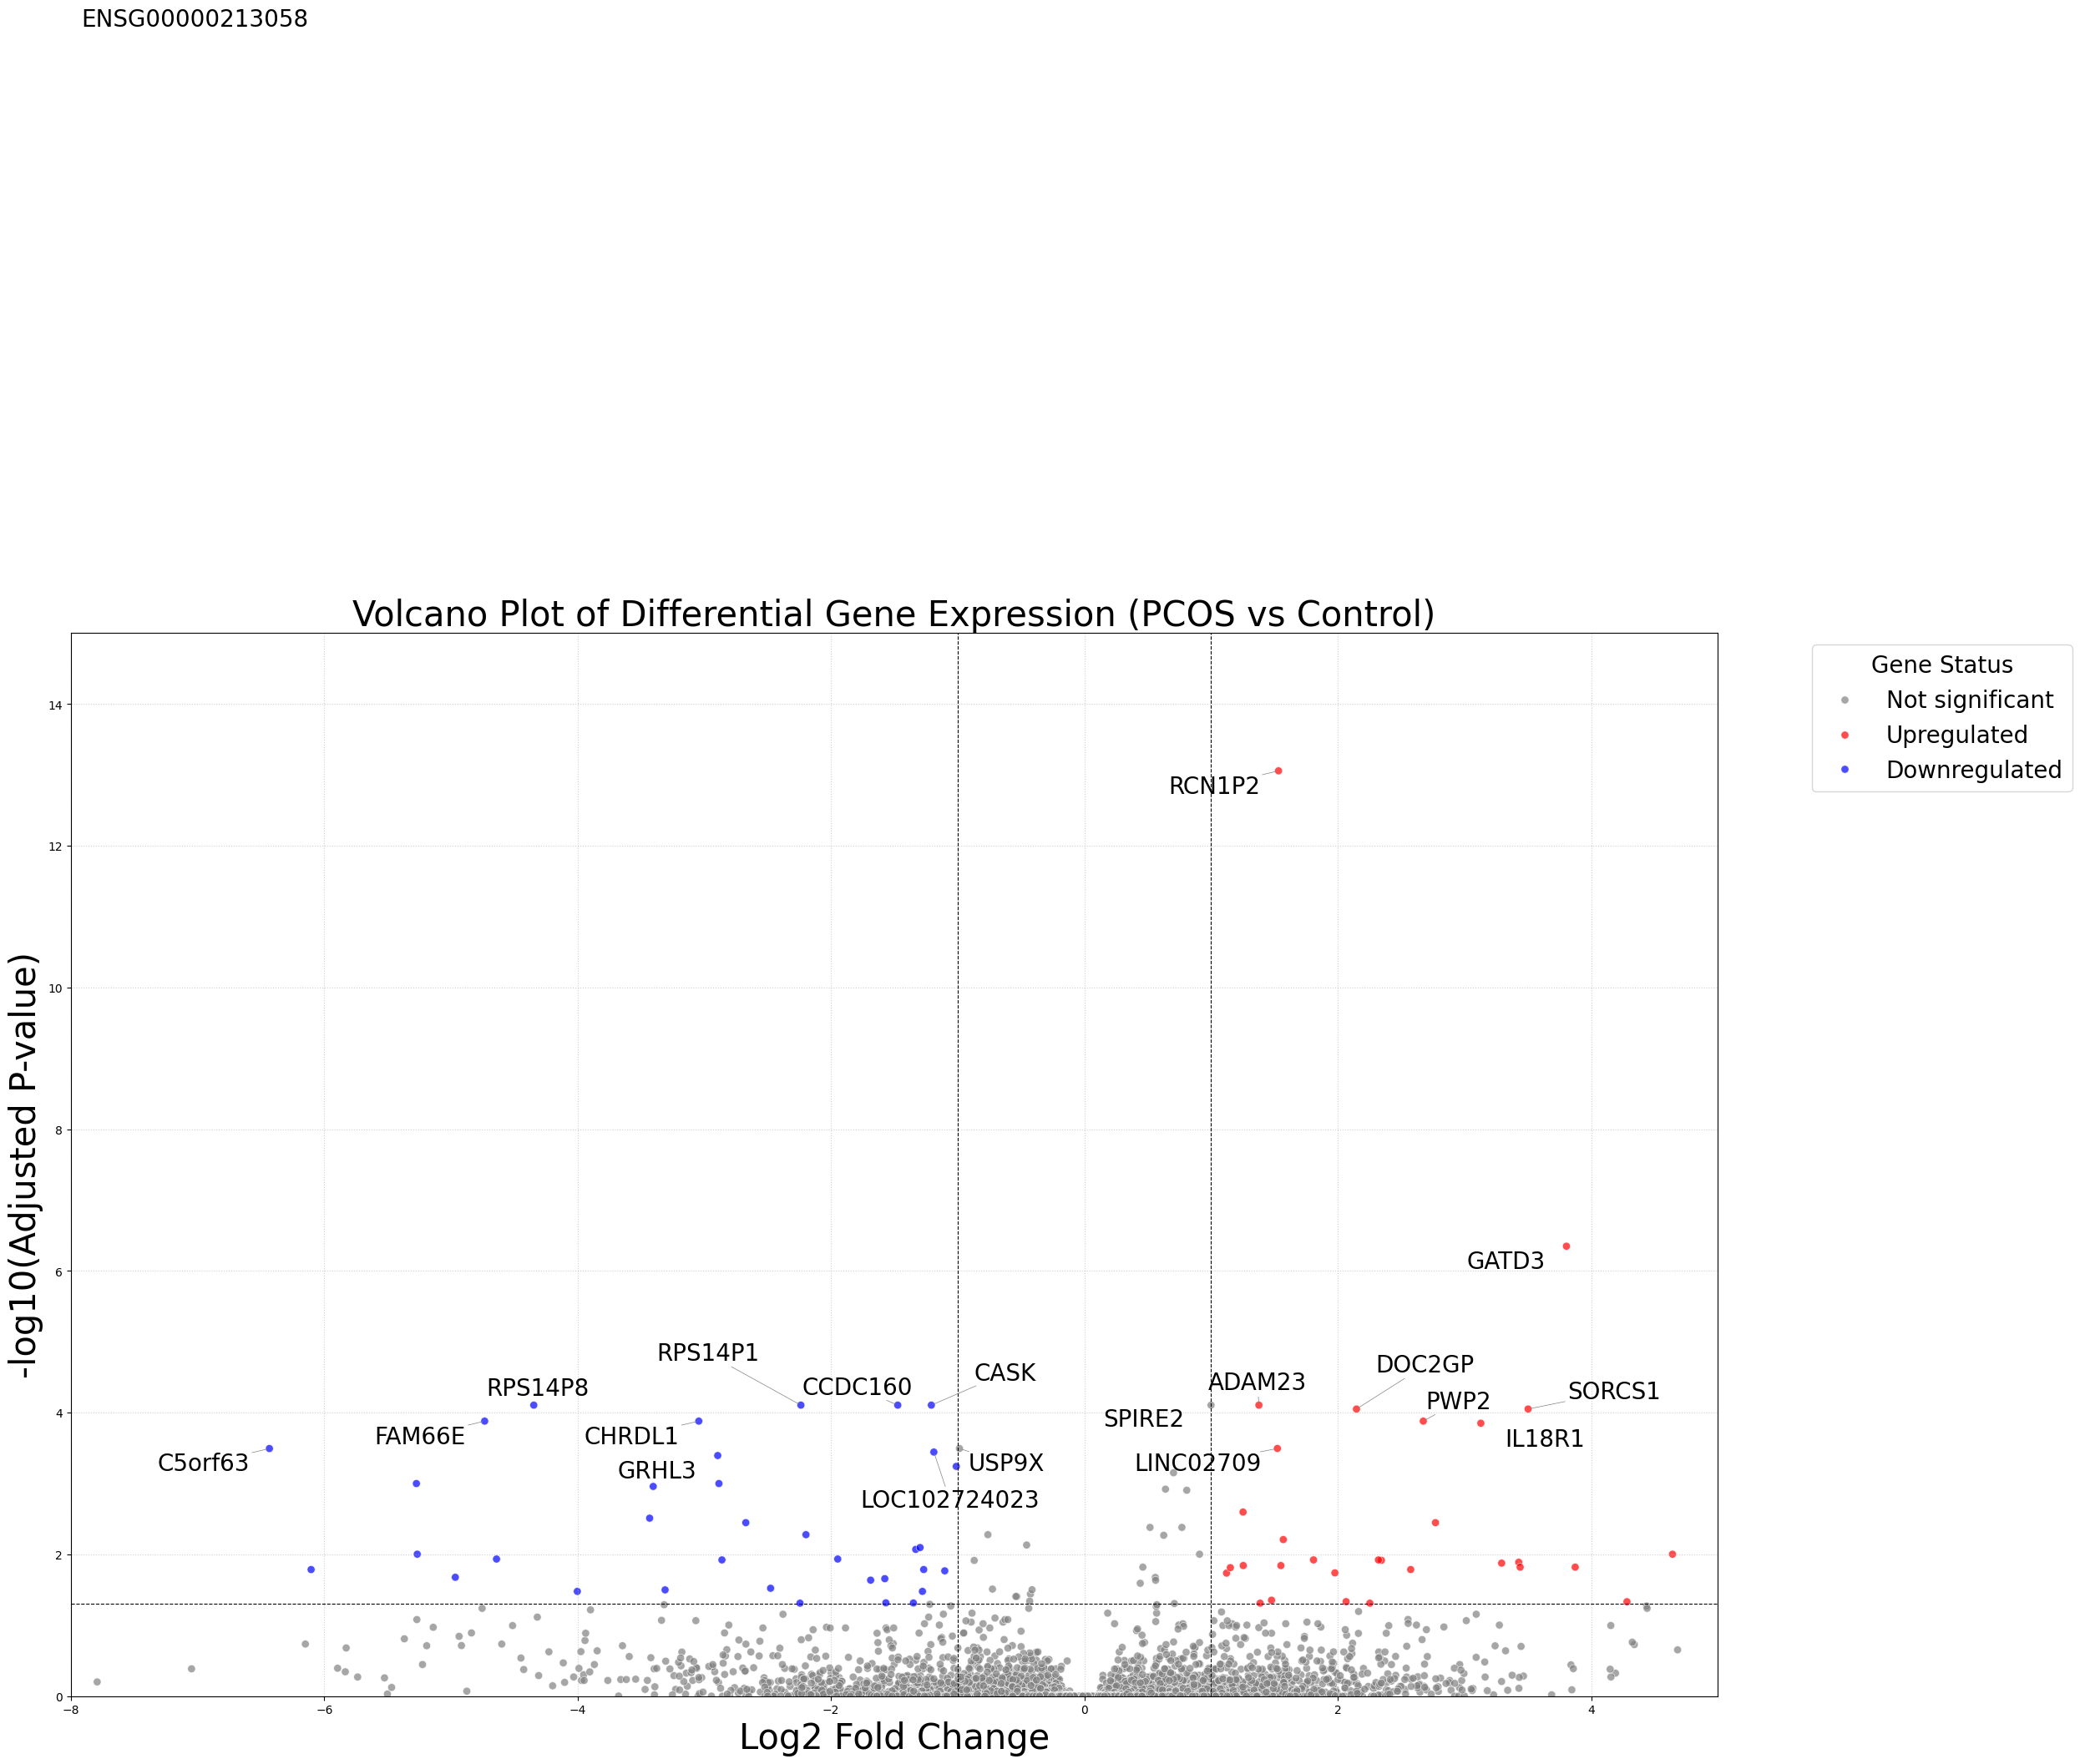

In [33]:
# Call the function to generate the labeled volcano plot with non-overlapping labels
plot_labeled_volcano(
    plot_df_labeled,
    genes_to_label,
    log2fc_threshold,
    p_adj_threshold,
    'Volcano Plot of Differential Gene Expression (PCOS vs Control)'
)

# Gene Regulatory Network

In [28]:
import pandas as pd
import numpy as np

# Extract normalized counts from your DESeq2 object
normalized_counts = dds.layers['normed_counts']  # or use dds.varm
expression_df = pd.DataFrame(normalized_counts,
                              index=dds.obs_names,
                              columns=dds.var_names).T

In [30]:
!pip install arboreto
from arboreto.algo import grnboost2
import pandas as pd
import numpy as np # Import numpy for numerical checks
from dask.distributed import Client, LocalCluster

# expression_df: genes as rows, samples as columns — transpose for arboreto
ex_matrix = expression_df.T  # samples x genes

diff_exp_gene_ids_versioned = differentially_expressed_genes.index.tolist()

genes_for_grn = [gene_id for gene_id in diff_exp_gene_ids_versioned if gene_id in ex_matrix.columns]

ex_matrix_filtered = ex_matrix[genes_for_grn]

# --- Data Cleaning for Stability ---
# 1. Handle potential NaN or Inf values by imputing with 0 or dropping. Given count data, NaNs might indicate missing values.
#    For GRN inference, 0 is often a safe imputation if there are no counts.
if ex_matrix_filtered.isnull().any().any():
    print("Warning: NaNs found in ex_matrix_filtered. Imputing with 0.")
    ex_matrix_filtered = ex_matrix_filtered.fillna(0)

# 2. Remove genes with zero variance across all samples, as these can cause numerical instability in some algorithms.
zero_variance_cols = ex_matrix_filtered.columns[ex_matrix_filtered.var(axis=0) == 0]
if not zero_variance_cols.empty:
    print(f"Warning: {len(zero_variance_cols)} genes with zero variance found. Removing them.")
    ex_matrix_filtered = ex_matrix_filtered.drop(columns=zero_variance_cols)

# Ensure all values are finite after any imputation
if not np.isfinite(ex_matrix_filtered).all().all():
    print("Warning: Non-finite values (Inf/-Inf) still present. Replacing with 0.")
    ex_matrix_filtered = ex_matrix_filtered.replace([np.inf, -np.inf], 0)


In [56]:
import pandas as pd

# Calculate the Pearson correlation matrix
correlation_matrix = ex_matrix_filtered.corr(method='pearson')

print("Spearman Correlation Matrix (first 5 rows and columns):")
display(correlation_matrix.head())

Spearman Correlation Matrix (first 5 rows and columns):


0,ENSG00000215790.7,ENSG00000158055.16,ENSG00000178965.14,ENSG00000171488.15,ENSG00000233593.10,ENSG00000007341.19,ENSG00000277147.6,ENSG00000143603.19,ENSG00000213058.3,ENSG00000224114.1,...,ENSG00000086717.18,ENSG00000044446.12,ENSG00000124486.13,ENSG00000215301.11,ENSG00000147044.22,ENSG00000133142.17,ENSG00000157502.13,ENSG00000089682.16,ENSG00000101938.15,ENSG00000203952.9
0,,,,,,,,,,,,,,,,,,,,,
ENSG00000215790.7,1.000000,-0.590804,-0.645886,-0.643971,0.867146,0.880942,0.602287,-0.766569,-0.822386,-0.780436,...,-0.695950,-0.748158,-0.815704,-0.668545,-0.759953,-0.691874,0.548461,-0.747404,-0.641722,-0.833122
ENSG00000158055.16,-0.590804,1.000000,0.974428,0.800697,-0.671457,-0.748182,-0.811201,0.515104,0.849317,0.822851,...,0.891919,0.613363,0.839504,0.811446,0.874965,0.882468,-0.701266,0.576038,0.745924,0.647730
ENSG00000178965.14,-0.645886,0.974428,1.000000,0.788301,-0.726854,-0.791306,-0.861505,0.672976,0.913936,0.905551,...,0.894376,0.689970,0.838921,0.842967,0.892303,0.920800,-0.790460,0.653534,0.811735,0.699599
ENSG00000171488.15,-0.643971,0.800697,0.788301,1.000000,-0.697031,-0.815670,-0.816768,0.489782,0.723062,0.685681,...,0.961628,0.813557,0.833237,0.706337,0.736513,0.749882,-0.676457,0.748643,0.534576,0.832109
ENSG00000233593.10,0.867146,-0.671457,-0.726854,-0.697031,1.000000,0.842748,0.749181,-0.728306,-0.783486,-0.785927,...,-0.758390,-0.717505,-0.774996,-0.617069,-0.734621,-0.765236,0.681398,-0.596938,-0.593371,-0.703922


Visualize Correlation Network

To visualize the correlation network,  follow these steps:

1.  **Define a correlation threshold:** We'll filter out correlations below a certain absolute value to focus on stronger relationships.
2.  **Create a graph:** We'll use the `networkx` library to build a graph where genes are nodes and edges represent correlations above our threshold.
3.  **Plot the graph:** We'll use `matplotlib` to draw the network, with different colors for positive and negative correlations.

The correlation matrix provides pairwise Pearson correlation coefficients between the expression levels of the differentially expressed genes. Values range from -1 to 1, where:

*   `1` indicates a perfect positive linear correlation.
*   `-1` indicates a perfect negative linear correlation.
*   `0` indicates no linear correlation.

In [57]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Define a correlation threshold
# Correlations with absolute values below this will be ignored.
correlation_threshold = 0.9 # You can adjust this value

# Create an empty graph
G = nx.Graph()

# Add nodes (genes) to the graph
genes = correlation_matrix.columns.tolist()
G.add_nodes_from(genes)

# Add edges based on the correlation matrix and threshold
# Iterate through the upper triangle of the correlation matrix to avoid duplicate edges
for i in range(len(genes)):
    for j in range(i + 1, len(genes)):
        gene1 = genes[i]
        gene2 = genes[j]
        correlation_value = correlation_matrix.loc[gene1, gene2]

        if abs(correlation_value) > correlation_threshold:
            # Add edge with correlation value as weight and color based on sign
            if correlation_value > 0:
                edge_color = 'skyblue'
            else:
                edge_color = 'salmon'

            G.add_edge(gene1, gene2, weight=correlation_value, color=edge_color)

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges (threshold: {correlation_threshold})")


Graph created with 86 nodes and 344 edges (threshold: 0.9)


In [58]:
import networkx as nx
import pandas as pd

# Calculate degree centrality for each node (gene)
degree_centrality = nx.degree_centrality(G)

# Convert to a pandas Series for easier sorting and analysis
degree_df = pd.Series(degree_centrality).sort_values(ascending=False)

print("Top 10 Hub Genes by Degree Centrality:")
# Display the top 10 genes with the highest degree centrality
# We'll map the Ensembl IDs to GeneSymbols for better readability if available
hub_genes_with_symbols = []
for gene_id, centrality_score in degree_df.head(10).items():
    unversioned_id = gene_id.split('.')[0]
    gene_symbol = None
    if gene_id in differentially_expressed_genes.index and pd.notna(differentially_expressed_genes.loc[gene_id, 'GeneSymbol']):
        gene_symbol = differentially_expressed_genes.loc[gene_id, 'GeneSymbol']
    else:
        gene_symbol = unversioned_id # Fallback to unversioned Ensembl ID
    hub_genes_with_symbols.append({'GeneID': gene_id, 'GeneSymbol': gene_symbol, 'Degree Centrality': centrality_score})

display(pd.DataFrame(hub_genes_with_symbols))


Top 10 Hub Genes by Degree Centrality:


,GeneID,GeneSymbol,Degree Centrality
0,ENSG00000148814.18,LRRC27,0.258824
1,ENSG00000110057.8,UNC93B1,0.235294
2,ENSG00000204991.11,SPIRE2,0.235294
3,ENSG00000239528.1,RPS14P8,0.211765
4,ENSG00000224114.1,RPS14P1,0.211765
5,ENSG00000277147.6,LINC00869,0.211765
6,ENSG00000140104.14,CLBA1,0.211765
7,ENSG00000231793.5,DOC2GP,0.188235
8,ENSG00000214455.4,RCN1P2,0.188235
9,ENSG00000157502.13,PWWP3B,0.188235


Degree Centrality Distribution




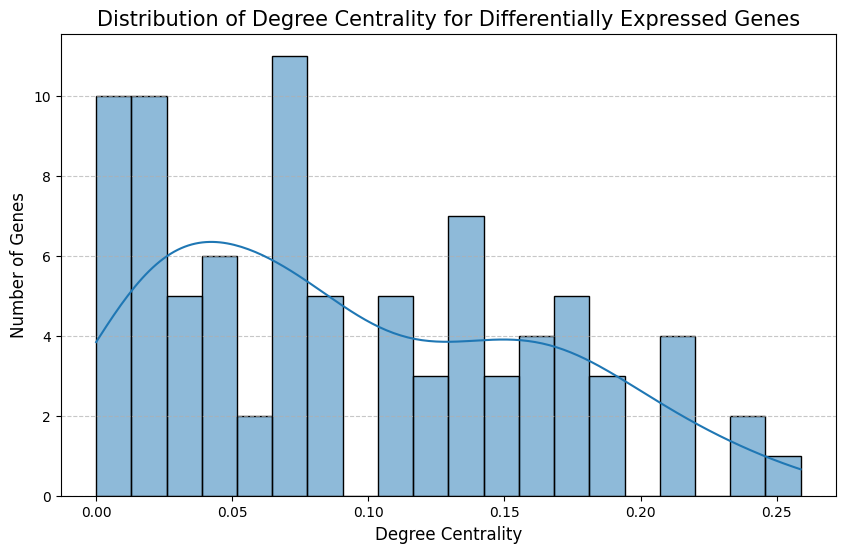

This histogram visualizes the distribution of degree centrality values across all differentially expressed genes.
A higher concentration of genes at certain centrality values indicates common connectivity patterns within the network.


In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert degree_df Series to DataFrame for easier plotting
degree_distribution_df = degree_df.reset_index()
degree_distribution_df.columns = ['GeneID', 'DegreeCentrality']

plt.figure(figsize=(10, 6))
sns.histplot(degree_distribution_df['DegreeCentrality'], kde=True, bins=20)
plt.title('Distribution of Degree Centrality for Differentially Expressed Genes', fontsize=15)
plt.xlabel('Degree Centrality', fontsize=12)
plt.ylabel('Number of Genes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("This histogram visualizes the distribution of degree centrality values across all differentially expressed genes.")
print("A higher concentration of genes at certain centrality values indicates common connectivity patterns within the network.")

DataFrame for centrality boxplot prepared (Hub vs Non-Hub). First 5 rows:


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10(padj),significance,GeneSymbol,DegreeCentrality,GeneCategory
ENSG00000215790.7,384.955023,1.122125,0.281557,3.985422,6.736036e-05,0.018358,1.736170,Upregulated,SLC35E2A,0.023529,Non-Hub Gene
ENSG00000158055.16,29.956322,-2.894274,0.573072,-5.050454,4.407623e-07,0.000402,3.395325,Downregulated,GRHL3,0.035294,Non-Hub Gene
ENSG00000178965.14,6.376822,-4.002659,1.052922,-3.801477,1.438362e-04,0.033246,1.478258,Downregulated,ERICH3,0.082353,Non-Hub Gene
ENSG00000171488.15,382.254173,-1.687147,0.430737,-3.916884,8.970097e-05,0.023070,1.636960,Downregulated,LRRC8C,0.023529,Non-Hub Gene
ENSG00000233593.10,41.195160,2.344547,0.564841,4.150808,3.313037e-05,0.012099,1.917243,Upregulated,LINC02609,0.035294,Non-Hub Gene


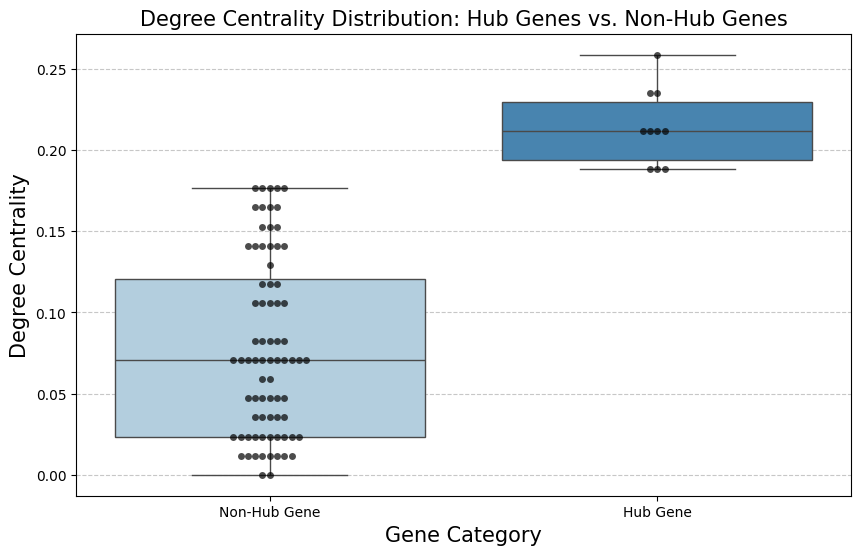

In [61]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert degree_df Series to DataFrame for merging
degree_df_reset = degree_df.reset_index()
degree_df_reset.columns = ['GeneID', 'DegreeCentrality']

# Merge with differentially_expressed_genes to get all differentially expressed genes
# (including those not in top 10 hubs, but still in the correlation network)
centrality_comparison_df = differentially_expressed_genes.merge(
    degree_df_reset.set_index('GeneID'),
    left_index=True,
    right_index=True,
    how='inner'
)

# Categorize genes as 'Hub Gene' or 'Non-Hub Gene'
centrality_comparison_df['GeneCategory'] = 'Non-Hub Gene'
centrality_comparison_df.loc[centrality_comparison_df.index.isin(top_10_hub_gene_ids), 'GeneCategory'] = 'Hub Gene'

print("DataFrame for centrality boxplot prepared (Hub vs Non-Hub). First 5 rows:")
display(centrality_comparison_df.head())

# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='GeneCategory', y='DegreeCentrality', data=centrality_comparison_df, palette='Blues', showfliers=False) # Hide outliers from boxplot, changed palette to Blues
sns.swarmplot(x='GeneCategory', y='DegreeCentrality', data=centrality_comparison_df, color='black', alpha=0.7) # Overlay individual points, changed color to black for contrast
plt.title('Degree Centrality Distribution: Hub Genes vs. Non-Hub Genes', fontsize = 15)
plt.xlabel('Gene Category', fontsize = 15)
plt.ylabel('Degree Centrality', fontsize = 15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Degree Centrality for Each Gene

## Gene Set Enrichment Analysis (GSEA) by Degree Centrality Quartiles

To understand the biological functions associated with genes having different levels of connectivity, we will perform Gene Set Enrichment Analysis (GSEA). We'll divide the genes into four quartiles based on their degree centrality and then run GSEA on each set of genes.

In [62]:
print("Installing gseapy library...")
!pip install gseapy -qq
print("gseapy library installed.")

Installing gseapy library...
gseapy library installed.


In [75]:
import gseapy
import pandas as pd
import numpy as np

# 1. Prepare a DataFrame with GeneID, GeneSymbol, and DegreeCentrality
# We start with degree_df (Series of EnsemblID -> DegreeCentrality)
degree_info_df = degree_df.reset_index()
degree_info_df.columns = ['EnsemblID', 'DegreeCentrality']

# Merge with differentially_expressed_genes to get GeneSymbols
# Ensure 'GeneSymbol' is extracted correctly, handling potential NaNs
degree_info_df = degree_info_df.merge(
    differentially_expressed_genes[['GeneSymbol']],
    left_on='EnsemblID',
    right_index=True,
    how='left'
)

# Fallback to EnsemblID if GeneSymbol is NaN
degree_info_df['GeneSymbol'] = degree_info_df['GeneSymbol'].fillna(degree_info_df['EnsemblID'].apply(lambda x: x.split('.')[0]))

# Sort by DegreeCentrality to facilitate quartile division
degree_info_df = degree_info_df.sort_values(by='DegreeCentrality', ascending=False).reset_index(drop=True)

# 2. Divide genes into quartiles based on Degree Centrality
degree_info_df['Quartile'] = pd.qcut(
    degree_info_df['DegreeCentrality'],
    q=4,
    labels=[1, 2, 3, 4], # Label quartiles from lowest to highest centrality
    duplicates='drop' # Handle cases where there might be duplicate centrality values
)

# If duplicates='drop' results in fewer than 4 unique labels, adjust labels manually if needed
# For simplicity, we'll proceed assuming 4 distinct labels are formed.

print("Genes assigned to quartiles based on Degree Centrality. First 10 rows:")
display(degree_info_df.head(10))
print("\nNumber of genes per quartile:")
print(degree_info_df['Quartile'].value_counts().sort_index())

# Create gene lists for each quartile using gene symbols
gene_lists_by_quartile = {}
for q in sorted(degree_info_df['Quartile'].unique()):
    genes_in_quartile = degree_info_df[degree_info_df['Quartile'] == q]['GeneSymbol'].tolist()
    # Filter out None values in case some symbols couldn't be resolved
    genes_in_quartile = [gene for gene in genes_in_quartile if gene is not None and gene != '']
    gene_lists_by_quartile[q] = genes_in_quartile

# Store Ensembl IDs for Quartile 4 for plotting
q4_ensembl_ids = degree_info_df[degree_info_df['Quartile'] == 4]['EnsemblID'].tolist()

print("\nGene lists prepared for each quartile.")


Genes assigned to quartiles based on Degree Centrality. First 10 rows:


,EnsemblID,DegreeCentrality,GeneSymbol,Quartile
0,ENSG00000148814.18,0.258824,LRRC27,4
1,ENSG00000110057.8,0.235294,UNC93B1,4
2,ENSG00000204991.11,0.235294,SPIRE2,4
3,ENSG00000239528.1,0.211765,RPS14P8,4
4,ENSG00000224114.1,0.211765,RPS14P1,4
5,ENSG00000277147.6,0.211765,LINC00869,4
6,ENSG00000140104.14,0.211765,CLBA1,4
7,ENSG00000231793.5,0.188235,DOC2GP,4
8,ENSG00000214455.4,0.188235,RCN1P2,4
9,ENSG00000157502.13,0.188235,PWWP3B,4



Number of genes per quartile:
Quartile
1    25
2    19
3    20
4    22
Name: count, dtype: int64

Gene lists prepared for each quartile.


### GSEA for Quartile 1 (Lowest Degree Centrality)

This quartile contains genes with the lowest connectivity in the network.

In [64]:
# Perform GSEA for Quartile 1
# Using 'GO_Biological_Process_2021' as an example gene set database
# You can choose other gene sets from gseapy.get_library_name()

q1_genes = gene_lists_by_quartile.get(1, [])

if q1_genes:
    print(f"Running GSEA for {len(q1_genes)} genes in Quartile 1...")
    enrichment_results_q1 = gseapy.enrichr(
        gene_list=q1_genes,
        gene_sets='GO_Biological_Process_2021', # Example database
        organism='homo sapiens', # or 'Mouse', 'Yeast', etc.
        outdir=None, # Set to a directory if you want to save results
        verbose=True,
        cutoff=0.05 # p-value cutoff
    )
    print("GSEA Results for Quartile 1 (top 10 terms by Adjusted P-value):")
    display(enrichment_results_q1.results.sort_values(by='Adjusted P-value').head(10))
else:
    print("No genes found in Quartile 1 for GSEA.")

Running GSEA for 25 genes in Quartile 1...


2026-05-08 18:22:50,573 [INFO] Online enrichment analysis with libraries: GO_Biological_Process_2021
2026-05-08 18:22:50,786 [INFO] Done.


GSEA Results for Quartile 1 (top 10 terms by Adjusted P-value):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,ventricular cardiac muscle tissue development ...,2/25,0.000442,0.077891,0,0,75.432892,582.634032,ISL1;HOPX
1,GO_Biological_Process_2021,positive regulation of fibroblast proliferatio...,2/28,0.000556,0.077891,0,0,66.719064,500.063177,CD74;PLA2G1B
2,GO_Biological_Process_2021,regulation of fibroblast proliferation (GO:004...,2/46,0.001501,0.077891,0,0,39.389328,256.092336,CD74;PLA2G1B
3,GO_Biological_Process_2021,positive regulation of interleukin-8 productio...,2/61,0.002624,0.077891,0,0,29.352985,174.448298,CD74;PLA2G1B
4,GO_Biological_Process_2021,positive regulation of protein secretion (GO:0...,2/72,0.003634,0.077891,0,0,24.726708,138.899703,PLA2G1B;ISL1
5,GO_Biological_Process_2021,positive regulation of immune response (GO:005...,2/75,0.003936,0.077891,0,0,23.706968,131.276850,CD74;PLA2G1B
6,GO_Biological_Process_2021,positive regulation of interleukin-6 productio...,2/76,0.004040,0.077891,0,0,23.385429,128.890540,CD74;ISL1
7,GO_Biological_Process_2021,regulation of interleukin-8 production (GO:003...,2/81,0.004575,0.077891,0,0,21.899835,117.977425,CD74;PLA2G1B
8,GO_Biological_Process_2021,sinoatrial node cell differentiation (GO:0060921),1/5,0.006235,0.077891,0,0,208.031250,1056.296661,ISL1
9,GO_Biological_Process_2021,regulation of granulocyte colony-stimulating f...,1/5,0.006235,0.077891,0,0,208.031250,1056.296661,ISL1


### GSEA for Quartile 2

In [65]:
# Perform GSEA for Quartile 2
q2_genes = gene_lists_by_quartile.get(2, [])

if q2_genes:
    print(f"Running GSEA for {len(q2_genes)} genes in Quartile 2...")
    enrichment_results_q2 = gseapy.enrichr(
        gene_list=q2_genes,
        gene_sets='GO_Biological_Process_2021',
        organism='homo sapiens', # Corrected from 'Human' to 'homo sapiens'
        outdir=None,
        verbose=True,
        cutoff=0.05
    )
    print("GSEA Results for Quartile 2 (top 10 terms by Adjusted P-value):")
    display(enrichment_results_q2.results.sort_values(by='Adjusted P-value').head(10))
else:
    print("No genes found in Quartile 2 for GSEA.")

Running GSEA for 19 genes in Quartile 2...


2026-05-08 18:22:53,230 [INFO] Online enrichment analysis with libraries: GO_Biological_Process_2021
2026-05-08 18:22:53,422 [INFO] Done.


GSEA Results for Quartile 2 (top 10 terms by Adjusted P-value):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,quinone catabolic process (GO:1901662),1/5,0.004741,0.118563,0,0,277.458333,1484.797350,NQO2
1,GO_Biological_Process_2021,proline transport (GO:0015824),1/6,0.005687,0.118563,0,0,221.955556,1147.410799,SLC6A15
2,GO_Biological_Process_2021,leucine transport (GO:0015820),1/6,0.005687,0.118563,0,0,221.955556,1147.410799,SLC6A15
3,GO_Biological_Process_2021,sequestering of BMP from receptor via BMP bind...,1/8,0.007576,0.118563,0,0,158.523810,774.035034,CHRDL1
4,GO_Biological_Process_2021,nervous system development (GO:0007399),3/447,0.008234,0.118563,0,0,8.250422,39.598208,ADAM23;DPF1;PCDHA6
5,GO_Biological_Process_2021,plasma membrane tubulation (GO:0097320),1/13,0.012283,0.136001,0,0,92.449074,406.730318,BIN3
6,GO_Biological_Process_2021,sequestering of extracellular ligand from rece...,1/14,0.013222,0.136001,0,0,85.333333,369.139021,CHRDL1
7,GO_Biological_Process_2021,pore complex assembly (GO:0046931),1/19,0.017904,0.151196,0,0,61.614198,247.856157,TSPAN33
8,GO_Biological_Process_2021,protein-containing complex assembly (GO:0065003),2/267,0.026146,0.151196,0,0,8.752941,31.896199,PARD6B;TSPAN33
9,GO_Biological_Process_2021,neutral amino acid transport (GO:0015804),1/28,0.026279,0.151196,0,0,41.057613,149.408063,SLC6A15


### GSEA for Quartile 3

In [66]:
# Perform GSEA for Quartile 3
q3_genes = gene_lists_by_quartile.get(3, [])

if q3_genes:
    print(f"Running GSEA for {len(q3_genes)} genes in Quartile 3...")
    enrichment_results_q3 = gseapy.enrichr(
        gene_list=q3_genes,
        gene_sets='GO_Biological_Process_2021',
        organism='homo sapiens', # Corrected from 'Human' to 'homo sapiens'
        outdir=None,
        verbose=True,
        cutoff=0.05
    )
    print("GSEA Results for Quartile 3 (top 10 terms by Adjusted P-value):")
    display(enrichment_results_q3.results.sort_values(by='Adjusted P-value').head(10))
else:
    print("No genes found in Quartile 3 for GSEA.")

Running GSEA for 20 genes in Quartile 3...


2026-05-08 18:22:55,631 [INFO] Online enrichment analysis with libraries: GO_Biological_Process_2021
2026-05-08 18:22:55,834 [INFO] Done.


GSEA Results for Quartile 3 (top 10 terms by Adjusted P-value):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,regulation of cell-matrix adhesion (GO:0001952),2/65,0.001903,0.095481,0,0,35.126984,220.050207,CASK;PTK2B
1,GO_Biological_Process_2021,synapse assembly (GO:0007416),2/69,0.002141,0.095481,0,0,33.023217,202.976255,DNER;PCDHB9
2,GO_Biological_Process_2021,negative regulation of cellular process (GO:00...,4/566,0.002143,0.095481,0,0,8.637900,53.084027,ST7L;DDX3X;CASK;PTK2B
3,GO_Biological_Process_2021,cell junction assembly (GO:0034329),2/102,0.004609,0.095481,0,0,22.088889,118.832322,DNER;PCDHB9
4,GO_Biological_Process_2021,regulation of inositol trisphosphate biosynthe...,1/5,0.004990,0.095481,0,0,262.842105,1393.123889,PTK2B
5,GO_Biological_Process_2021,mature ribosome assembly (GO:0042256),1/5,0.004990,0.095481,0,0,262.842105,1393.123889,DDX3X
6,GO_Biological_Process_2021,positive regulation of translation in response...,1/5,0.004990,0.095481,0,0,262.842105,1393.123889,DDX3X
7,GO_Biological_Process_2021,endothelin receptor signaling pathway (GO:0086...,1/5,0.004990,0.095481,0,0,262.842105,1393.123889,PTK2B
8,GO_Biological_Process_2021,activation of Janus kinase activity (GO:0042976),1/6,0.005986,0.095481,0,0,210.263158,1076.207481,PTK2B
9,GO_Biological_Process_2021,positive regulation of toll-like receptor 7 si...,1/6,0.005986,0.095481,0,0,210.263158,1076.207481,DDX3X


### GSEA for Quartile 4 (Highest Degree Centrality)

This quartile contains genes with the highest connectivity (hub genes) in the network.

In [67]:
# Perform GSEA for Quartile 4
q4_genes = gene_lists_by_quartile.get(4, [])

if q4_genes:
    print(f"Running GSEA for {len(q4_genes)} genes in Quartile 4...")
    enrichment_results_q4 = gseapy.enrichr(
        gene_list=q4_genes,
        gene_sets='GO_Biological_Process_2021',
        organism='homo sapiens', # Corrected from 'Human' to 'homo sapiens'
        outdir=None,
        verbose=True,
        cutoff=0.05
    )
    print("GSEA Results for Quartile 4 (top 10 terms by Adjusted P-value):")
    display(enrichment_results_q4.results.sort_values(by='Adjusted P-value'))
else:
    print("No genes found in Quartile 4 for GSEA.")

Running GSEA for 22 genes in Quartile 4...


2026-05-08 18:22:58,802 [INFO] Online enrichment analysis with libraries: GO_Biological_Process_2021
2026-05-08 18:22:59,005 [INFO] Done.


GSEA Results for Quartile 4 (top 10 terms by Adjusted P-value):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,positive regulation of T-helper 1 cell cytokin...,1/5,0.005488,0.083665,0,0,237.785714,1237.703279,IL18R1
1,GO_Biological_Process_2021,regulation of T-helper 1 cell cytokine product...,1/5,0.005488,0.083665,0,0,237.785714,1237.703279,IL18R1
2,GO_Biological_Process_2021,positive regulation of DNA demethylation (GO:1...,1/5,0.005488,0.083665,0,0,237.785714,1237.703279,USP9X
3,GO_Biological_Process_2021,protein deubiquitination involved in ubiquitin...,1/6,0.006583,0.083665,0,0,190.219048,955.531692,USP9X
4,GO_Biological_Process_2021,regulation of DNA demethylation (GO:1901535),1/6,0.006583,0.083665,0,0,190.219048,955.531692,USP9X
...,...,...,...,...,...,...,...,...,...,...
104,GO_Biological_Process_2021,cytokine-mediated signaling pathway (GO:0019221),1/621,0.500576,0.519645,0,0,1.486790,1.028854,IL18R1
105,GO_Biological_Process_2021,negative regulation of transcription by RNA po...,1/684,0.535120,0.550264,0,0,1.345256,0.841141,USP9X
106,GO_Biological_Process_2021,"negative regulation of transcription, DNA-temp...",1/948,0.656613,0.668886,0,0,0.956957,0.402554,USP9X
107,GO_Biological_Process_2021,cellular protein modification process (GO:0006...,1/1025,0.685899,0.692250,0,0,0.881417,0.332316,PHKA2


In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming enrichment_results_q1, enrichment_results_q2, enrichment_results_q3, enrichment_results_q4 are available
# and are gseapy.enrichr.EnrichrResult objects.

# Define the number of top terms to consider from each quartile
num_top_terms = 20 # Adjust as needed

all_quartile_results = {
    'Quartile_1': enrichment_results_q1,
    'Quartile_2': enrichment_results_q2,
    'Quartile_3': enrichment_results_q3,
    'Quartile_4': enrichment_results_q4,
}

# Collect top terms and their Combined Scores from each quartile
combined_scores_data = []
all_terms = set()

for q_name, enrichr_result in all_quartile_results.items():
    if enrichr_result and not enrichr_result.results.empty:
        # Sort by 'Adjusted P-value' and then take 'num_top_terms'
        top_terms_df = enrichr_result.results.sort_values(by='Adjusted P-value').head(num_top_terms)
        for index, row in top_terms_df.iterrows():
            term = row['Term']
            combined_score = row['Combined Score']
            combined_scores_data.append({'Term': term, 'Quartile': q_name, 'Combined_Score': combined_score})
            all_terms.add(term)

# Create a DataFrame from the collected data
heatmap_df = pd.DataFrame(combined_scores_data)

# Pivot the DataFrame to get Terms as index and Quartiles as columns, with Combined_Score as values
# We take the maximum score if a term appears multiple times in a quartile (e.g., if num_top_terms allows it)
heatmap_pivot = heatmap_df.pivot_table(index='Term', columns='Quartile', values='Combined_Score', aggfunc='max')

# Filter for terms that appear in at least two quartiles to focus on shared pathways
# Or, uncomment the line below to show all terms collected across all top lists
# heatmap_pivot = heatmap_pivot[heatmap_pivot.notna().sum(axis=1) >= 1]

# Sort by overall enrichment or by first quartile for better visualization
# heatmap_pivot = heatmap_pivot.sort_values(by=list(heatmap_pivot.columns), ascending=False)

print(f"Heatmap data prepared for {len(heatmap_pivot)} terms. Top 5 rows:")
display(heatmap_pivot.head())

Heatmap data prepared for 80 terms. Top 5 rows:


Quartile,Quartile_1,Quartile_2,Quartile_3,Quartile_4
Term,,,,
His-Purkinje system development (GO:0003164),1056.296661,NaN,NaN,NaN
actin filament network formation (GO:0051639),NaN,NaN,NaN,420.260566
activation of Janus kinase activity (GO:0042976),NaN,NaN,1076.207481,NaN
amino acid transport (GO:0006865),NaN,69.355781,NaN,NaN
bicellular tight junction assembly (GO:0070830),NaN,64.132587,NaN,NaN


In [71]:
import re

# Function to remove GO ID from a term string
def remove_go_id(term):
    # Regular expression to find and remove (GO:XXXXXXXX) pattern
    return re.sub(r' \(GO:\d+\)', '', term).strip()

# Apply the function to the 'Term' column of heatmap_df
heatmap_df['Term'] = heatmap_df['Term'].apply(remove_go_id)

# Re-pivot the DataFrame with the cleaned terms
heatmap_pivot = heatmap_df.pivot_table(index='Term', columns='Quartile', values='Combined_Score', aggfunc='max')

print("GO IDs removed from terms in heatmap_df. Updated heatmap_pivot:")
display(heatmap_pivot.head())

GO IDs removed from terms in heatmap_df. Updated heatmap_pivot:


Quartile,Quartile_1,Quartile_2,Quartile_3,Quartile_4
Term,,,,
His-Purkinje system development,1056.296661,NaN,NaN,NaN
actin filament network formation,NaN,NaN,NaN,420.260566
activation of Janus kinase activity,NaN,NaN,1076.207481,NaN
amino acid transport,NaN,69.355781,NaN,NaN
bicellular tight junction assembly,NaN,64.132587,NaN,NaN


With the GO IDs removed from the terms, let's re-plot the heatmaps to reflect this change.

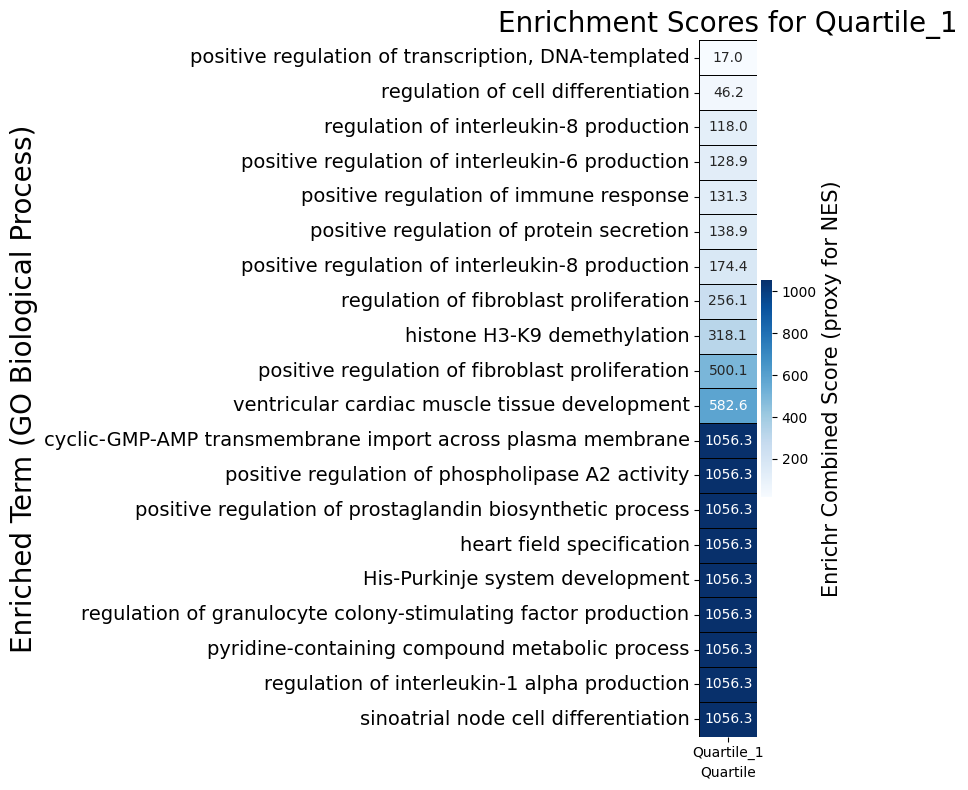

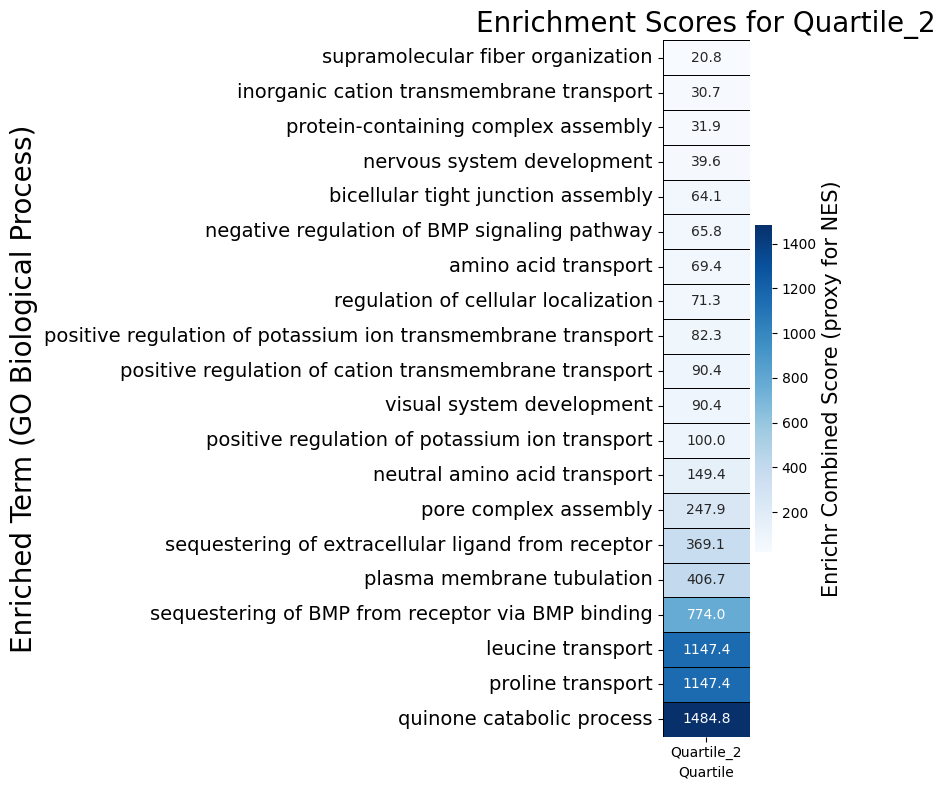

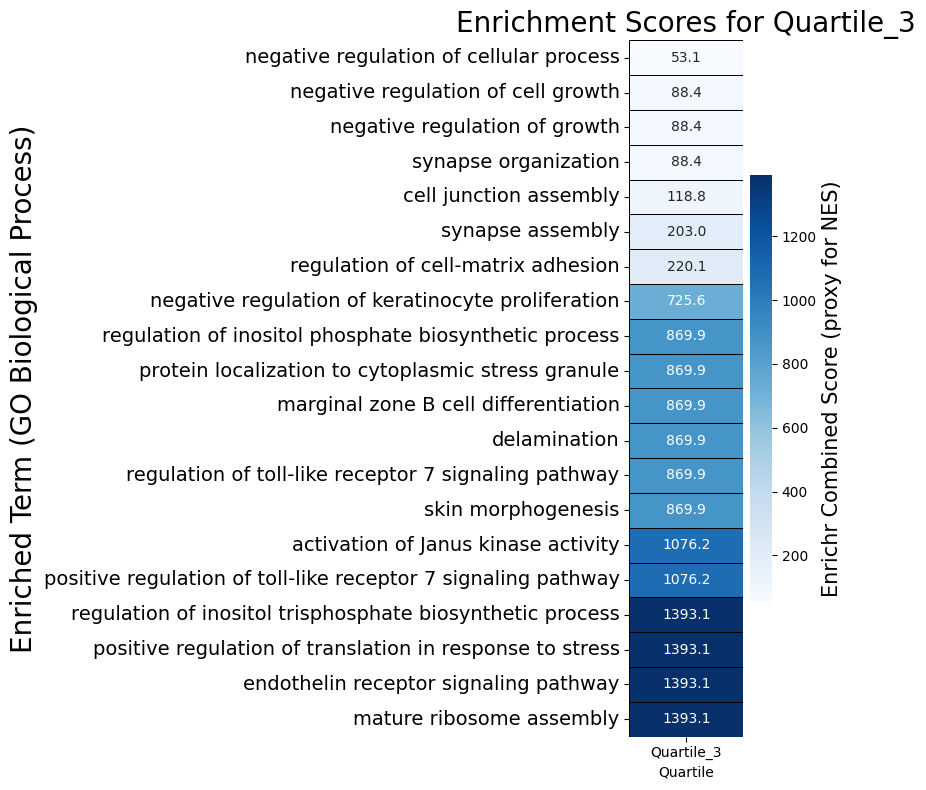

/tmp/ipykernel_8031/4176574861.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


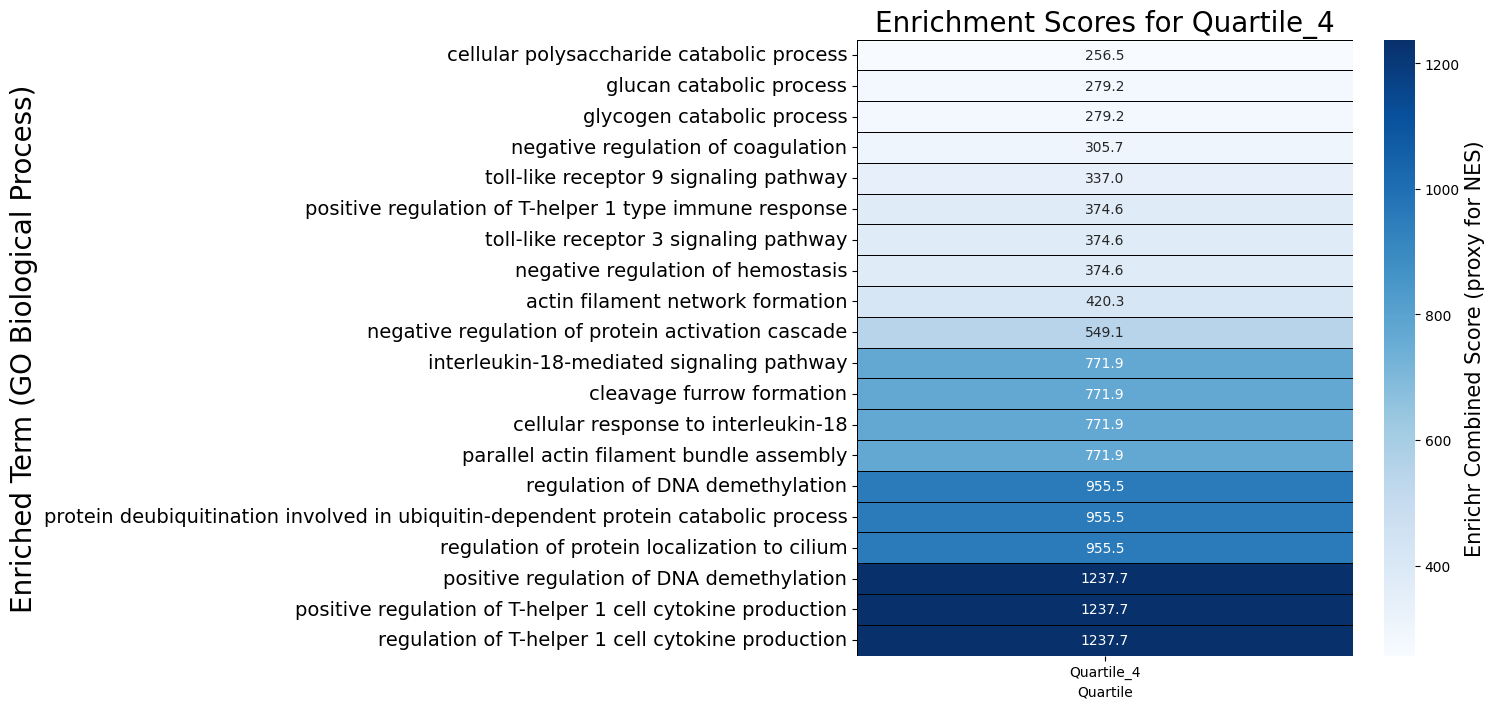

These heatmaps visualize the 'Combined Score' (proxy for NES) for the top enriched terms within each degree centrality quartile. Higher scores indicate stronger enrichment.


In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Loop through each quartile and create a separate heatmap
for q_name in ['Quartile_1', 'Quartile_2', 'Quartile_3', 'Quartile_4']: # Corrected names to use underscores
    # Extract data for the current quartile
    # Filter the heatmap_df to include only terms present in the current quartile's top terms
    current_quartile_data = heatmap_df[heatmap_df['Quartile'] == q_name].pivot_table(index='Term', columns='Quartile', values='Combined_Score', aggfunc='max')

    if not current_quartile_data.empty:
        # Sort the terms by their Combined Score in ascending order for this quartile
        current_quartile_data = current_quartile_data.sort_values(by=q_name, ascending=True)

        plt.figure(figsize=(8, max(6, len(current_quartile_data) * 0.4))) # Adjust figure size dynamically

        # Plot the heatmap
        ax = sns.heatmap( # Assign the plot to an ax object to get the colorbar
            current_quartile_data.fillna(0), # Fill NaN with 0 for visualization purposes
            cmap='Blues',       # Color map for the heatmap
            linewidths=.5,        # Lines between cells
            linecolor='black',    # Color of lines
            annot=True,           # Show the score values on the heatmap
            fmt=".1f",            # Format annotation to one decimal place
            cbar_kws={'label': 'Enrichr Combined Score (proxy for NES)'} # Removed fontsize from here
        )

        # Get the colorbar object and set its label's fontsize
        cbar = ax.collections[0].colorbar
        cbar.set_label('Enrichr Combined Score (proxy for NES)', fontsize=15) # Set fontsize here

        plt.title(f'Enrichment Scores for {q_name}', fontsize=20)
        plt.ylabel('Enriched Term (GO Biological Process)', fontsize=20)
        plt.yticks(rotation=0, fontsize = 14)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No data to plot for {q_name}. This could be due to no significant terms found in this quartile or a naming mismatch.")

print("These heatmaps visualize the 'Combined Score' (proxy for NES) for the top enriched terms within each degree centrality quartile. Higher scores indicate stronger enrichment.")

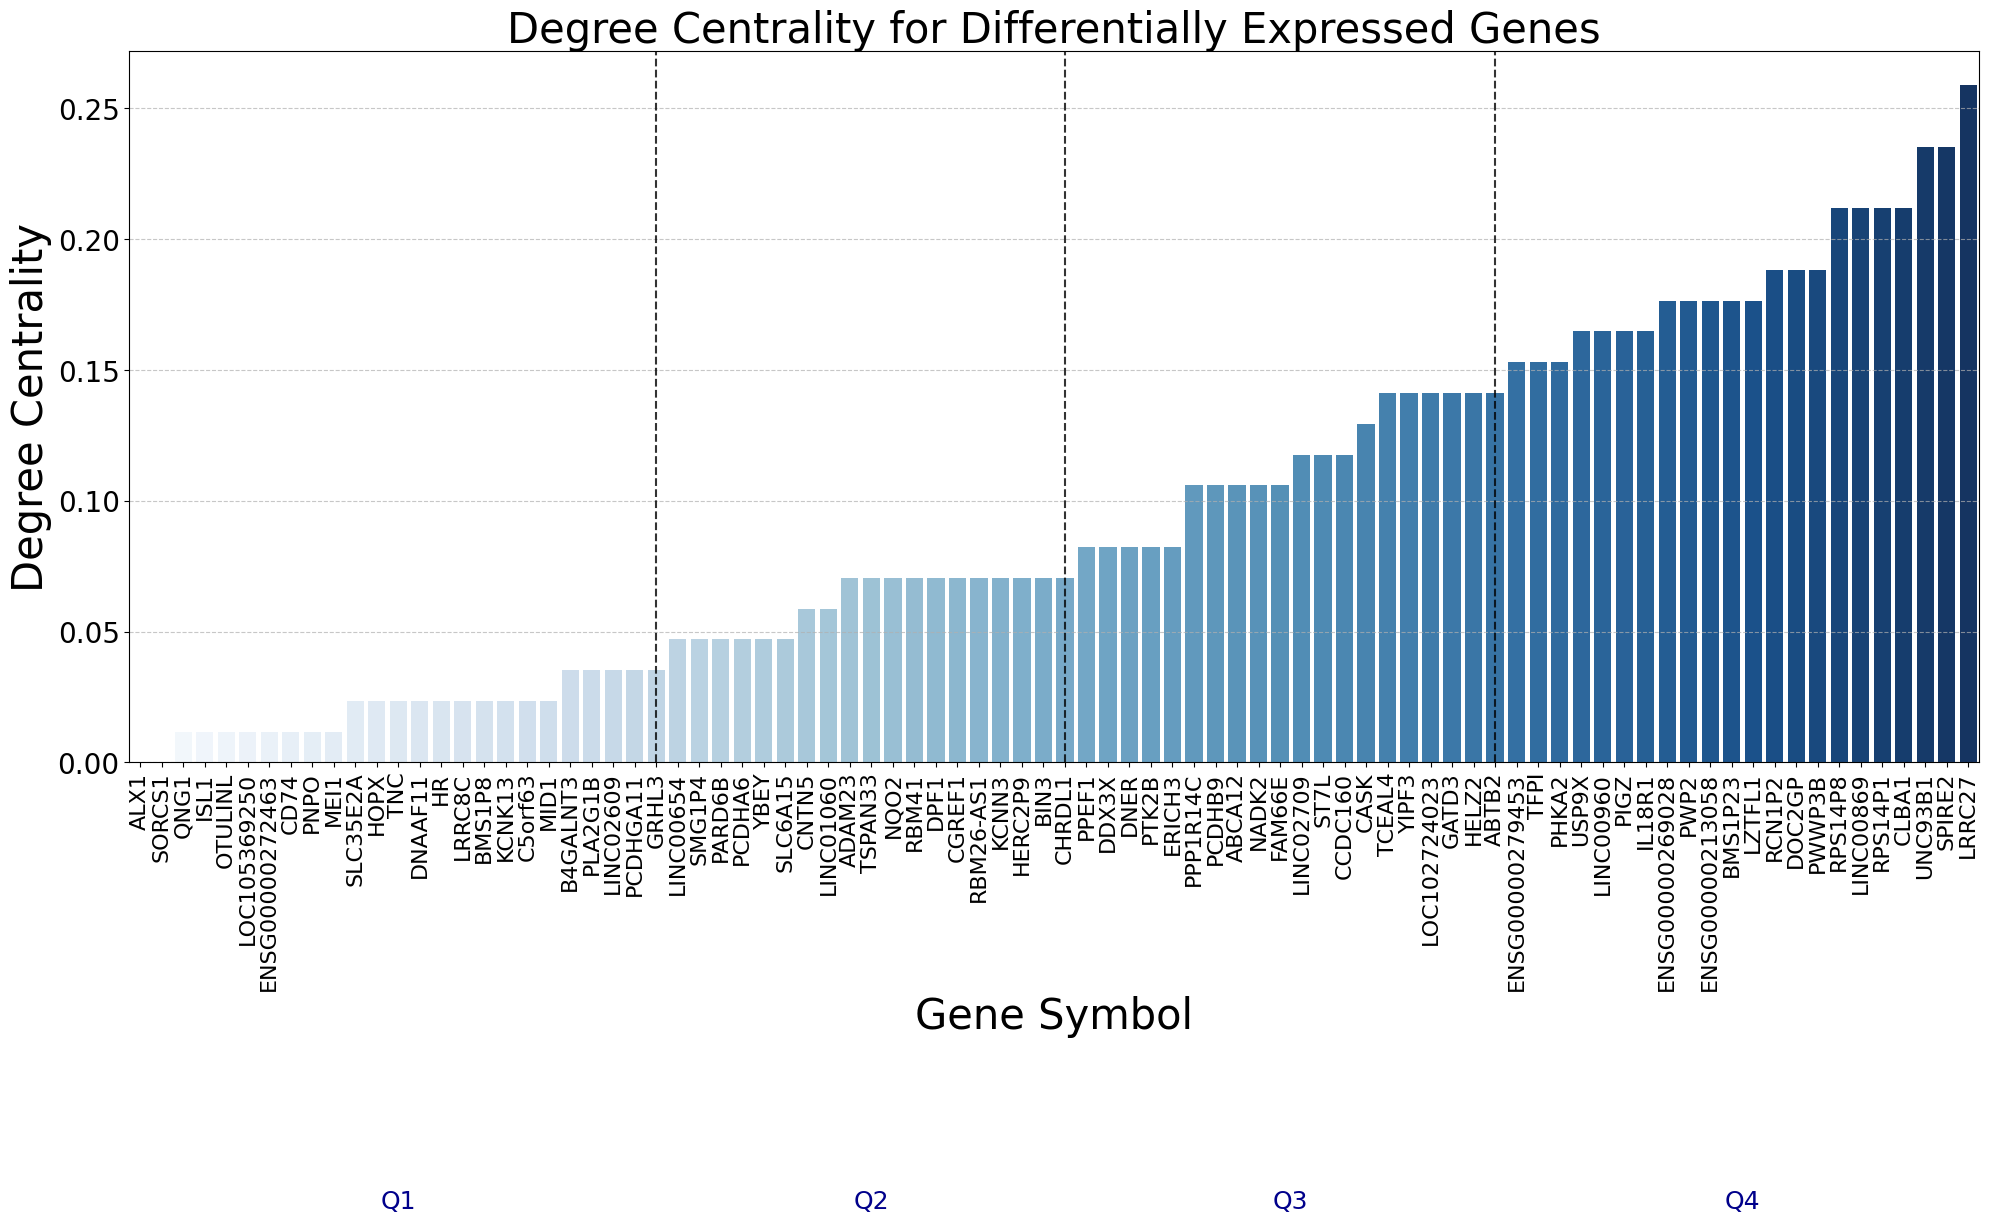

This plot shows the degree centrality value for each differentially expressed gene, sorted from lowest to highest. Vertical lines now delineate the quartiles, and quartile labels are added at the bottom.


In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use degree_info_df which already has the 'Quartile' column and is sorted.
# We need to sort it ascending for the plot to show lowest centrality first.
plot_data = degree_info_df.sort_values(by='DegreeCentrality', ascending=True).copy()

# Ensure 'DisplayGene' column is present for x-axis labels
plot_data['DisplayGene'] = plot_data['GeneSymbol'].fillna(plot_data['EnsemblID'].apply(lambda x: x.split('.')[0]))

plt.figure(figsize=(20, 15)) # Increase figure size for better readability of gene labels
sns.barplot(x='DisplayGene', y='DegreeCentrality', data=plot_data, palette='Blues')
plt.title('Degree Centrality for Differentially Expressed Genes', fontsize=30)
plt.xlabel('Gene Symbol', fontsize=30) # Changed label to 'Gene Symbol'
plt.ylabel('Degree Centrality', fontsize=30)
plt.xticks(rotation=90, fontsize=16) # Rotate x-axis labels for better visibility and reduced font size for readability
plt.yticks(fontsize = 20)

# Add vertical lines to delineate quartiles
# We need to find the x-axis positions where each quartile ends.

# Get the unique quartile values in ascending order
unique_quartiles = sorted(plot_data['Quartile'].unique())

# Initialize a list to store x-positions for vertical lines
vertical_line_positions = []
current_position = -0.5 # Start before the first bar

for q_label in unique_quartiles:
    # Get the number of genes in the current quartile
    num_genes_in_quartile = plot_data[plot_data['Quartile'] == q_label].shape[0]
    # The vertical line should be placed after the last gene of the current quartile
    current_position += num_genes_in_quartile
    if q_label < max(unique_quartiles): # Don't draw a line after the last quartile
        vertical_line_positions.append(current_position - 0.5) # Adjust for bar width (0.5 for half bar width)

# Draw vertical lines
for x_pos in vertical_line_positions:
    plt.axvline(x=x_pos, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

# Add labels for the quartiles below the x-axis
# Find the center position for each quartile
quartile_centers = []
start_index = 0
for q_label in unique_quartiles:
    num_genes = plot_data[plot_data['Quartile'] == q_label].shape[0]
    center = start_index + (num_genes / 2) - 0.5 # Adjust for x-axis indexing to center text within quartile
    quartile_centers.append(center)
    start_index += num_genes

for i, center in enumerate(quartile_centers):
    plt.text(center, plt.ylim()[0] - 0.6 * (plt.ylim()[1] - plt.ylim()[0]), # Position slightly below x-axis
             f'Q{unique_quartiles[i]}', # Label with Quartile number
             ha='center', va='top', fontsize=18, color='darkblue',
             transform=plt.gca().transData)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

print("This plot shows the degree centrality value for each differentially expressed gene, sorted from lowest to highest. Vertical lines now delineate the quartiles, and quartile labels are added at the bottom.")

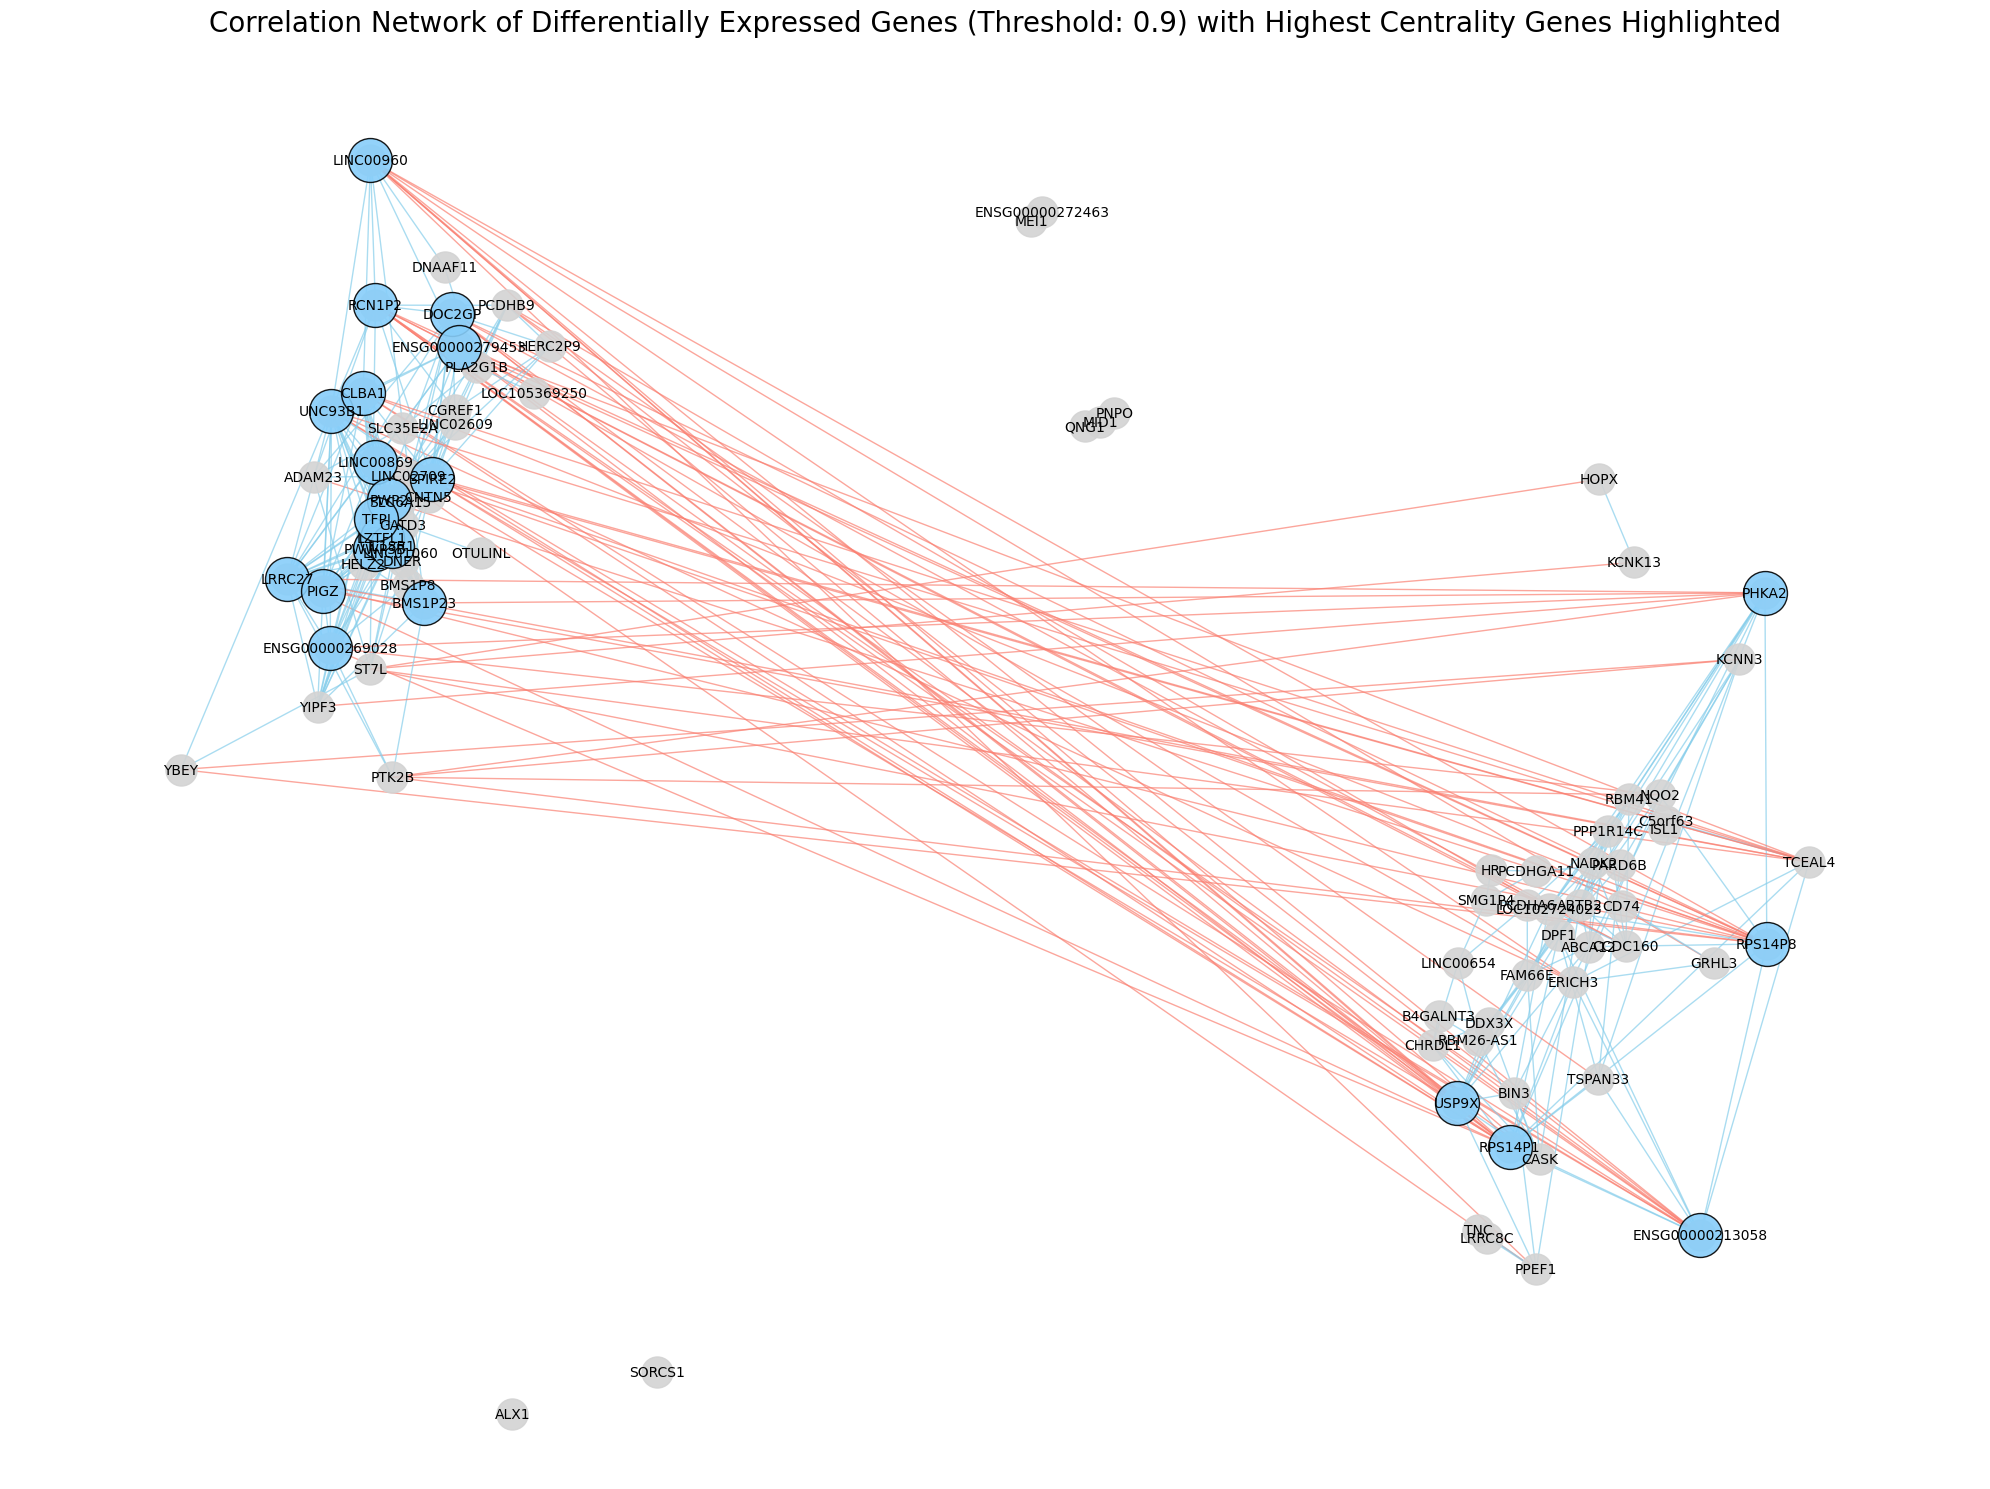

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare for plotting

# Get node positions for visualization using a spring layout
pos = nx.spring_layout(G, k=0.05, iterations=50) # k regulates the distance between nodes

# Get edge colors for plotting
edges = G.edges()
colors = [G[u][v]['color'] for u,v in edges]

# Set figure size, adjusted for potentially many labels
plt.figure(figsize=(20, 15)) # Further increased figure size

# Draw all nodes initially with a default style
nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightgray', alpha=0.9) # Increased node size

# Draw hub genes with a different color and larger size to highlight them
nx.draw_networkx_nodes(G, pos, nodelist=q4_ensembl_ids, node_size=1000, node_color='lightskyblue', alpha=0.9, linewidths=1.0, edgecolors='black') # Increased node size

# Draw edges
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=colors, width=1, alpha=0.7)

# Create labels for ALL genes in the network
node_labels_all = {}
for gene_id in G.nodes():
    unversioned_id = gene_id.split('.')[0]
    # Check if the gene is in differentially_expressed_genes and has a symbol
    if gene_id in differentially_expressed_genes.index and pd.notna(differentially_expressed_genes.loc[gene_id, 'GeneSymbol']):
        node_labels_all[gene_id] = differentially_expressed_genes.loc[gene_id, 'GeneSymbol']
    else:
        node_labels_all[gene_id] = unversioned_id # Fallback to unversioned Ensembl ID

nx.draw_networkx_labels(G, pos, labels=node_labels_all, font_size=10, font_color='black') # Increased font_size

plt.title(f'Correlation Network of Differentially Expressed Genes (Threshold: {correlation_threshold}) with Highest Centrality Genes Highlighted', size=20) # Increased title size
plt.axis('off') # Hide axes
plt.tight_layout()
plt.show()

### Correlation Network with Only Hub Genes Labeled

This visualization focuses on the most highly connected genes (hub genes) by labeling only them, which can improve clarity in dense networks. All other genes are still present as nodes but remain unlabeled.

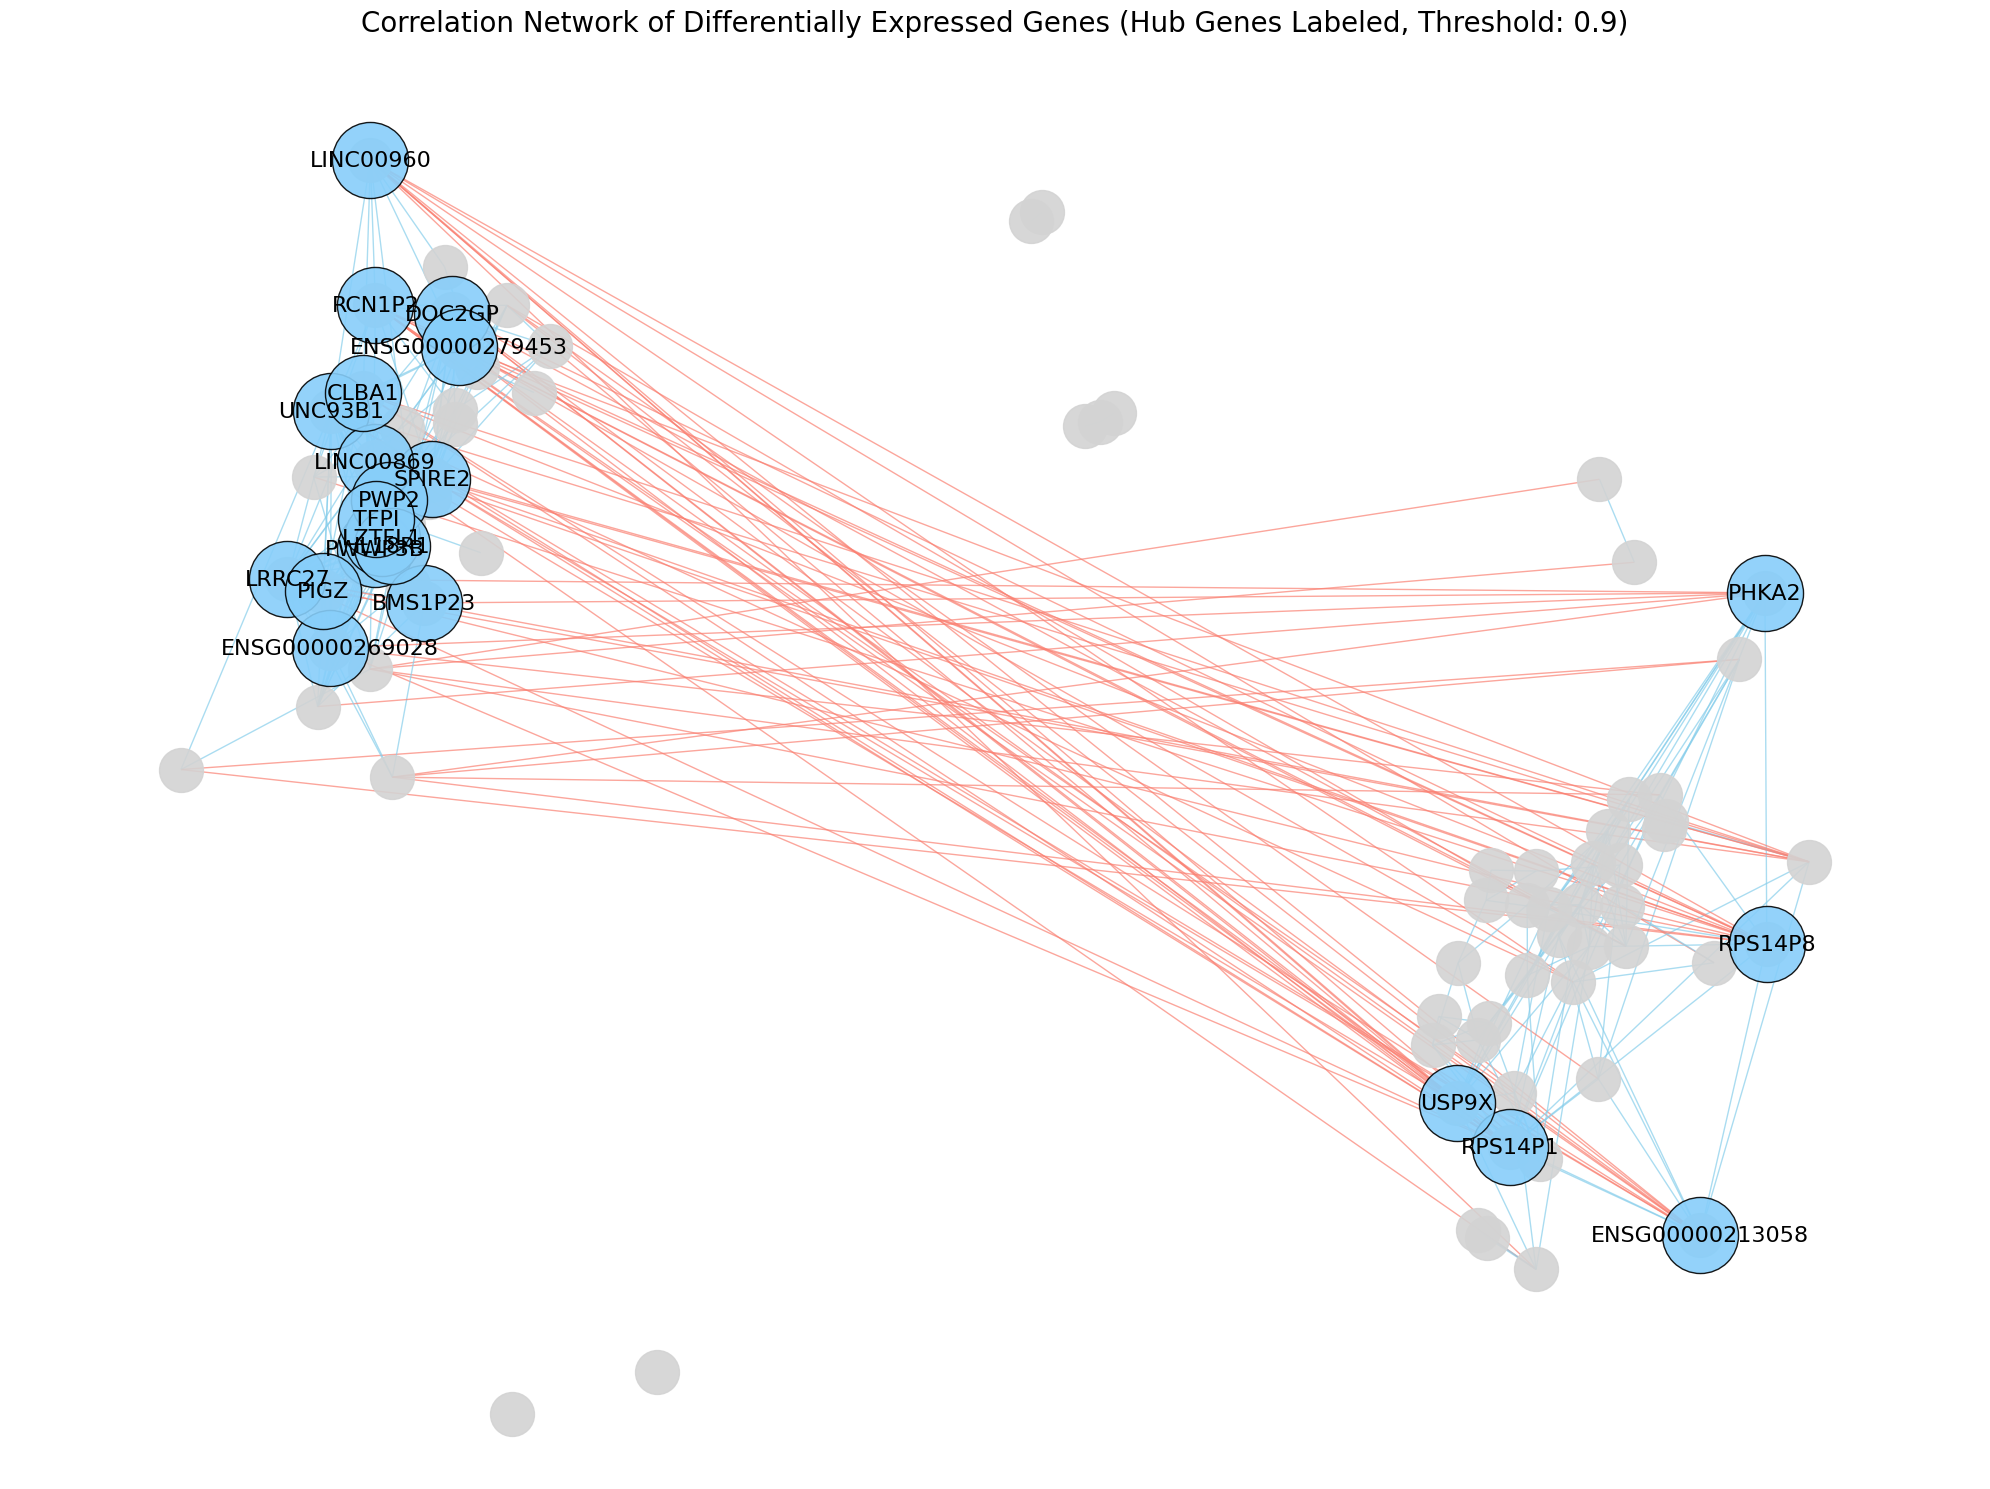

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare for plotting (reusing already computed elements like G, pos, edges, colors)

# Set figure size, adjusted for potentially many labels
plt.figure(figsize=(20, 15)) # Further increased figure size

# Draw all nodes initially with a default style
nx.draw_networkx_nodes(G, pos, node_size=1000, node_color='lightgray', alpha=0.9) # Increased node size

# Draw hub genes with a different color and larger size to highlight them
nx.draw_networkx_nodes(G, pos, nodelist=q4_ensembl_ids, node_size=3000, node_color='lightskyblue', alpha=0.9, linewidths=1.0, edgecolors='black') # Increased node size

# Draw edges
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=colors, width=1, alpha=0.7)

# Create labels ONLY for hub genes (q4_ensembl_ids)
node_labels_q4_only = {}
for gene_id in q4_ensembl_ids:
    unversioned_id = gene_id.split('.')[0]
    # Check if the gene is in differentially_expressed_genes and has a symbol
    if gene_id in differentially_expressed_genes.index and pd.notna(differentially_expressed_genes.loc[gene_id, 'GeneSymbol']):
        node_labels_q4_only[gene_id] = differentially_expressed_genes.loc[gene_id, 'GeneSymbol']
    else:
        node_labels_q4_only[gene_id] = unversioned_id # Fallback to unversioned Ensembl ID

nx.draw_networkx_labels(G, pos, labels=node_labels_q4_only, font_size=16, font_color='black') # Increased font_size

plt.title(f'Correlation Network of Differentially Expressed Genes (Hub Genes Labeled, Threshold: {correlation_threshold})', size=20) # Increased title size
plt.axis('off') # Hide axes
plt.tight_layout()
plt.show()